# Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
from sklearn.model_selection import LeaveOneOut
import numpy as np
import pdb
from imblearn.over_sampling import SMOTE
from collections import Counter
print("okay")

okay


In [2]:
# file_path = '\\Users\\Muhammad Aqib\\Desktop\\ASD experiments\\Waves data Individual Trajectories-modified.xlsx'
file_path = '/home/tanvirdell3/Downloads/ASDvsControl/Waves data Individual Trajectories-modified.xlsx'

In [3]:
asd_data = pd.read_excel(file_path, sheet_name="ASD", skiprows=0, nrows=237)
control_data = pd.read_excel(file_path, sheet_name="Control", skiprows=0, nrows=237)

In [4]:
asd_data.head()

,Unnamed: 0,a9,Unnamed: 2,a9.1,Unnamed: 4,a9.2,Unnamed: 6,a9.3,Unnamed: 8,a9.4,...,Unnamed: 2040,GA039.13,Unnamed: 2042,GA039a.11,Unnamed: 2044,GA039.14,Unnamed: 2046,GA039a.12,Unnamed: 2048,GA039.15
0,NaN,1.204,NaN,0.799,NaN,1.114,NaN,-0.119,NaN,0.602,...,NaN,0.949,NaN,0.949,NaN,-0.119,NaN,-0.119,NaN,0.398000
1,ms,uV,ms,uV,ms,uV,ms,uV,ms,uV,...,ms,uV,ms,uV,ms,uV,ms,uV,ms,-1.451156
2,-20.383944,0.559658,-20.506761,0.19251,-20.467819,-1.932362,-20.128734,0.553445,-20.459502,1.308576,...,-20.161003,0.859969,-20.406877,0.730124,-20.393932,-0.124611,-20.321136,0.912734,-20.396224,-1.405032
3,-19.871944,0.541656,-19.994761,0.16781,-19.955819,-1.843291,-19.616734,0.515173,-19.947502,1.256268,...,-19.649003,0.819289,-19.894877,0.695424,-19.881932,-0.143917,-19.809136,0.857609,-19.884224,-1.355873
4,-19.359944,0.520374,-19.482761,0.145697,-19.443819,-1.753148,-19.104734,0.471246,-19.435502,1.205094,...,-19.137003,0.779519,-19.382877,0.663297,-19.369932,-0.147496,-19.297136,0.7966,-19.372224,-1.303679


In [5]:
# Drop all columns starting with "Unnamed"
asd_data = asd_data.loc[:, ~asd_data.columns.str.startswith('Unnamed')]
control_data = control_data.loc[:, ~control_data.columns.str.startswith('Unnamed')]
print('*')

*


In [6]:
control_data.shape

(237, 1563)

# All flash strength avg id wise data

In [49]:
group_columns = [
    'a10', 'a100', 'a20', 'a21', 'a22', 'a23b', 'a25', 'a27', 'a28', 'a29',
    'a3', 'a31', 'a33', 'a34', 'a36', 'a37', 'a43', 'a46', 'a47', 'a48',
    'a5', 'a52', 'A60', 'a61', 'a7', 'a9', 'GA002b', 'GA003b', 'GA006','GA006a','GA006b','GA006c'
    'GA008', 'GA010', 'GA012', 'GA014', 'GA017', 'GA018', 'GA019', 'GA023',
    'GA027', 'GA028', 'GA029', 'GA030', 'GA031', 'GA037', 'GA038', 'GA039'
]
group_columns_c = [
    'C009', 'C010', 'C011b', 'C013', 'C015', 'C016', 'C017', 'C018', 'C019',
    'C020', 'C021', 'C024', 'C025', 'C028', 'C029', 'C031', 'C032', 'C035',
    'C036', 'C039', 'C041', 'C047', 'C049', 'C050', 'c1', 'c10', 'c105', 'c14',
    'c2', 'c4', 'c40', 'c400', 'c41', 'c42', 'c44', 'c45', 'c5', 'c50', 'c52',
    'c53', 'c55', 'c56', 'c6', 'c60', 'c61', 'c64', 'c65', 'c66', 'c67', 'c68',
    'c7', 'c71', 'c77', 'c78', 'c8', 'c80', 'c81', 'c83', 'c84', 'c9'
]
final_df_asd = pd.DataFrame()
final_df_control = pd.DataFrame()

for group in group_columns:
    # 1. Select columns that match exactly after splitting by '.'
    matching_cols = [col for col in asd_data.columns if col.split('.')[0] == group]
    if not matching_cols:
        continue  # Skip if no matching columns found
    # 2. Create sub-dataframe
    temp_df_a = asd_data[matching_cols]
   
    temp_df_a = temp_df_a.iloc[2:].reset_index(drop=True)
    final_df_asd[group] = temp_df_a.mean(axis=1)

for group in group_columns_c:
    # 1. Select columns that match exactly after splitting by '.'
    matching_cols = [col for col in control_data.columns if col.split('.')[0] == group]
    if not matching_cols:
        continue  # Skip if no matching columns found
    # 2. Create sub-dataframe
    temp_df_c = control_data[matching_cols]
   
    temp_df_c = temp_df_c.iloc[2:].reset_index(drop=True)
    final_df_control[group] = temp_df_c.mean(axis=1)
    
final_df_control.shape, final_df_asd.shape

((235, 60), (235, 46))

# ASD Filteres with respective flash strength

In [7]:
# filter out asd data using particular flash strength
# Your list of main group names
group_columns = [
    'a10', 'a100', 'a20', 'a21', 'a22', 'a23b', 'a25', 'a27', 'a28', 'a29',
    'a3', 'a31', 'a33', 'a34', 'a36', 'a37', 'a43', 'a46', 'a47', 'a48',
    'a5', 'a52', 'A60', 'a61', 'a7', 'a', 'a9', 'GA002b', 'GA003b', 'GA006','GA006a','GA006b','GA006c'
    'GA008', 'GA010', 'GA012', 'GA014', 'GA017', 'GA018', 'GA019', 'GA023',
    'GA027', 'GA028', 'GA029', 'GA030', 'GA031', 'GA037', 'GA038', 'GA039'
]

# Create empty DataFrame to collect results
final_df_asd = pd.DataFrame()

for group in group_columns:
    # 1. Select columns that match exactly after splitting by '.'
    matching_cols = [col for col in asd_data.columns if col.split('.')[0] == group]
    
    if not matching_cols:
        continue  # Skip if no matching columns found
    
    # 2. Create sub-dataframe
    temp_df = asd_data[matching_cols]
    
    # 3. Select columns where first row == 1.204
    selected_cols = temp_df.columns[temp_df.iloc[0] == 0.114]
    
    if selected_cols.empty:
        #pdb.set_trace()
        continue  # Skip if no columns satisfy first row == 1.204

    # 4. Keep only selected columns
    selected_data = temp_df[selected_cols]
    
    # 5. Drop first two rows and reset index
    selected_data = selected_data.drop(index=[0, 1]).reset_index(drop=True)

    # 6. Take mean across selected columns
    final_df_asd[group] = selected_data.mean(axis=1)

# Done! Final_df has one column per group
final_df_asd.head()


,a10,a100,a20,a21,a22,a23b,a25,a27,a28,a29,...,GA019,GA023,GA027,GA028,GA029,GA030,GA031,GA037,GA038,GA039
0,-1.426932,0.403915,0.452131,-0.688947,-0.010986,-0.812406,-0.091102,-1.655389,0.246753,0.153692,...,-0.367419,-0.389643,0.656516,0.849032,-0.063941,-0.170721,-0.005872,-1.699773,0.856889,0.620323
1,-1.313743,0.374856,0.43074,-0.647738,0.006956,-0.79048,-0.107251,-1.568895,0.256015,0.183335,...,-0.348641,-0.344615,0.783783,0.842827,-0.007557,-0.141473,0.001497,-1.622214,0.806365,0.598287
2,-1.198068,0.34667,0.411247,-0.6226,0.022916,-0.753309,-0.121045,-1.474697,0.268638,0.19981,...,-0.330603,-0.304948,0.873356,0.828395,0.053555,-0.114242,0.009483,-1.539767,0.753256,0.569718
3,-1.079908,0.319357,0.393652,-0.613534,0.036891,-0.700891,-0.132484,-1.372794,0.28462,0.203117,...,-0.313304,-0.270641,0.925237,0.805732,0.119396,-0.089028,0.018086,-1.452432,0.697562,0.534616
4,-0.959262,0.292916,0.377955,-0.620539,0.048884,-0.633226,-0.141567,-1.263186,0.303962,0.193257,...,-0.296744,-0.241695,0.939424,0.774841,0.189966,-0.065831,0.027306,-1.360208,0.639283,0.492982


# Filtered control data with respect to flash strength 

In [8]:
# filter out control data using particular flash strength
# Your list of main group names
group_columns_c = [
    'C009', 'C010', 'C011b', 'C013', 'C015', 'C016', 'C017', 'C018', 'C019',
    'C020', 'C021', 'C024', 'C025', 'C028', 'C029', 'C031', 'C032', 'C035',
    'C036', 'C039', 'C041', 'C047', 'C049', 'C050', 'c1', 'c10', 'c105', 'c14',
    'c2', 'c4', 'c40', 'c400', 'c41', 'c42', 'c44', 'c45', 'c5', 'c50', 'c52',
    'c53', 'c55', 'c56', 'c6', 'c60', 'c61', 'c64', 'c65', 'c66', 'c67', 'c68',
    'c7', 'c71', 'c77', 'c78', 'c8', 'c80', 'c81', 'c83', 'c84', 'c9'
]

# Create empty DataFrame to collect results
final_df_control = pd.DataFrame()

for group in group_columns_c:
    # 1. Select columns that match exactly after splitting by '.'
    matching_cols = [col for col in control_data.columns if col.split('.')[0] == group]
    
    if not matching_cols:
        continue  # Skip if no matching columns found
    
    # 2. Create sub-dataframe
    temp_df = control_data[matching_cols]
    
    # 3. Select columns where first row == 1.204
    selected_cols = temp_df.columns[temp_df.iloc[0] == 0.114]
    
    if selected_cols.empty:
        continue  # Skip if no columns satisfy first row == 1.204

    # 4. Keep only selected columns
    selected_data = temp_df[selected_cols]
    
    # 5. Drop first two rows and reset index
    selected_data = selected_data.drop(index=[0, 1]).reset_index(drop=True)

    # 6. Take mean across selected columns
    final_df_control[group] = selected_data.mean(axis=1)

# Done! Final_df has one column per group
final_df_control.head()


,C009,C010,C011b,C013,C015,C016,C017,C018,C019,C020,...,c7,c71,c77,c78,c8,c80,c81,c83,c84,c9
0,0.969616,-0.252801,1.190295,0.470349,-0.1144,-0.020626,0.163039,0.577093,-0.340486,-0.25012,...,-0.174518,-0.15368,0.797882,0.937744,0.394478,-0.499482,-0.488311,0.766523,-0.311623,0.323785
1,0.844183,-0.222852,1.158436,0.453861,-0.119013,-0.008101,0.136837,0.573833,-0.346296,-0.239844,...,-0.169344,-0.203198,0.771704,0.881887,0.4059,-0.483318,-0.3595,0.763302,-0.326402,0.282988
2,0.735707,-0.19011,1.12219,0.43757,-0.12171,-0.004028,0.130014,0.568706,-0.350376,-0.220749,...,-0.147955,-0.256143,0.747563,0.818708,0.412395,-0.464726,-0.25602,0.751443,-0.344371,0.241677
3,0.644189,-0.154574,1.081558,0.421477,-0.122488,-0.008407,0.142571,0.561712,-0.352727,-0.192836,...,-0.110351,-0.312517,0.725459,0.748205,0.413964,-0.443705,-0.177872,0.730947,-0.365529,0.199854
4,0.569629,-0.116245,1.036539,0.405582,-0.12135,-0.021237,0.174507,0.552851,-0.353348,-0.156103,...,-0.056531,-0.372318,0.705392,0.670379,0.410605,-0.420256,-0.125055,0.701813,-0.389877,0.157517


# Plotting

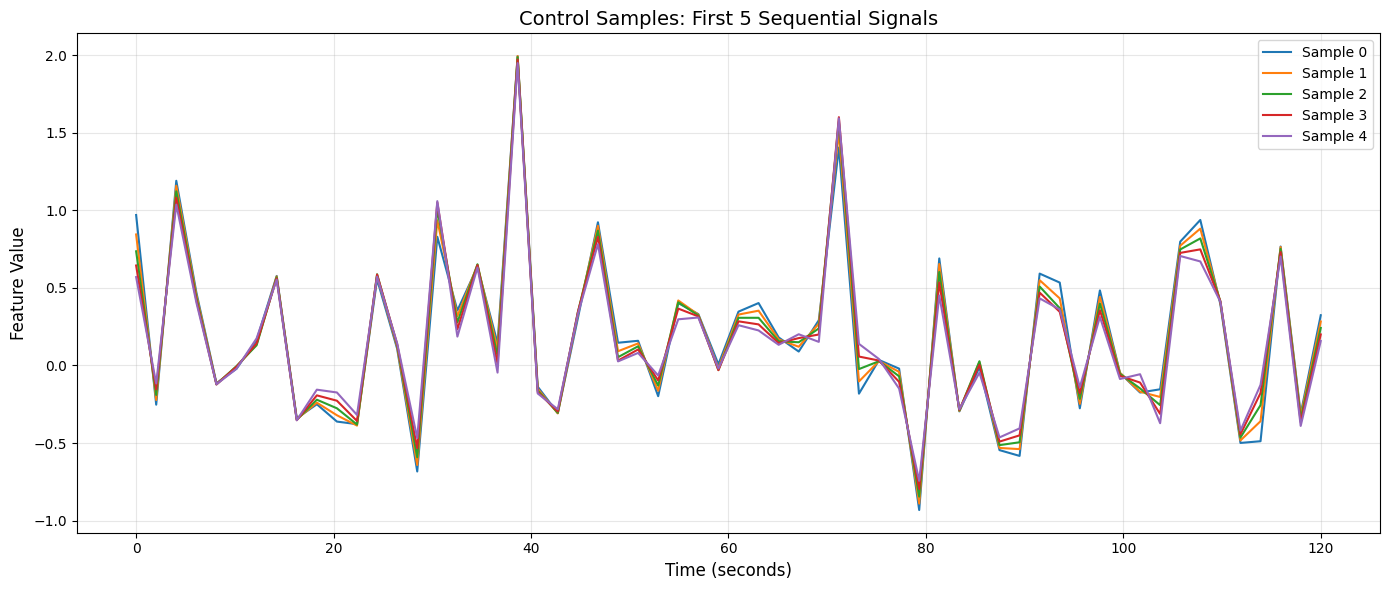

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 6))

# Create time axis from 0 to 120 sec with 235 steps
time_axis = np.linspace(0, 120, final_df_control.shape[1])

# Plot first 5 samples
for i in range(min(5, final_df_control.shape[0])):
    plt.plot(time_axis, final_df_control.iloc[i], label=f'Sample {i}', linewidth=1.5)

# Customize plot
plt.title("Control Samples: First 5 Sequential Signals", fontsize=14)
plt.xlabel("Time (seconds)", fontsize=12)
plt.ylabel("Feature Value", fontsize=12)
plt.xticks(np.arange(0, 121, 20))  # X-axis ticks: 0, 20, ..., 120
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


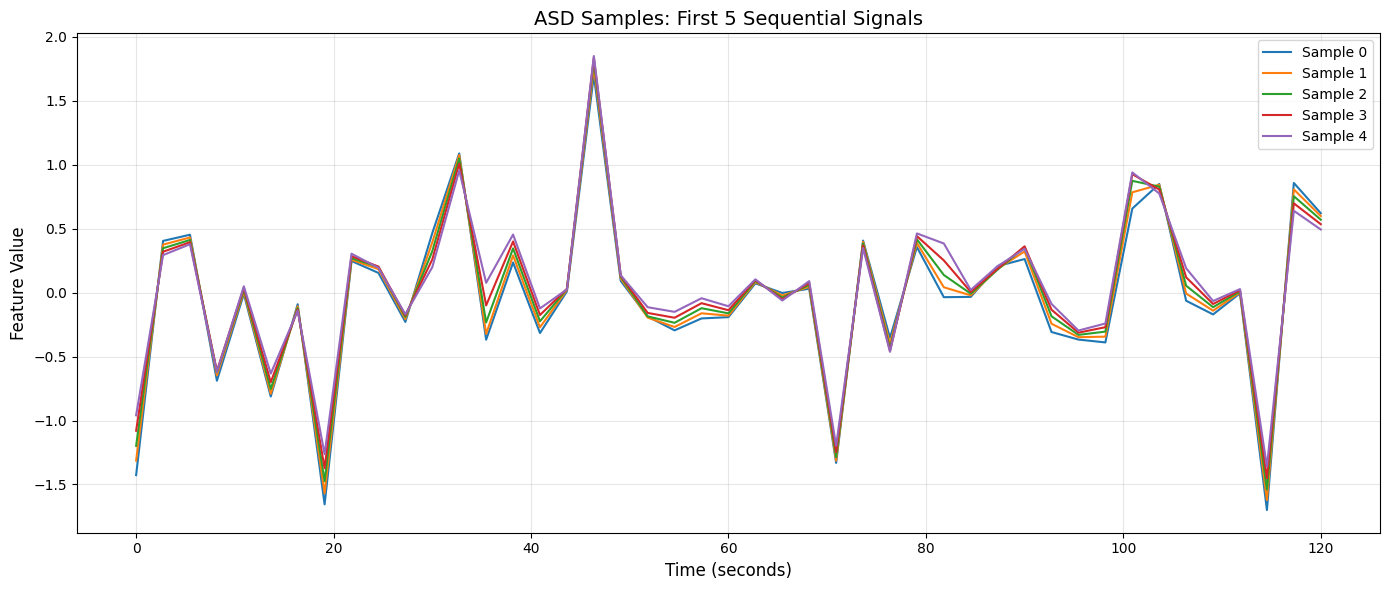

In [10]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 6))

# Create time axis from 0 to 120 sec with 235 steps
time_axis = np.linspace(0, 120, final_df_asd.shape[1])

# Plot first 5 samples
for i in range(min(5, final_df_asd.shape[0])):
    plt.plot(time_axis, final_df_asd.iloc[i], label=f'Sample {i}', linewidth=1.5)

# Customize plot
plt.title("ASD Samples: First 5 Sequential Signals", fontsize=14)
plt.xlabel("Time (seconds)", fontsize=12)
plt.ylabel("Feature Value", fontsize=12)
plt.xticks(np.arange(0, 121, 20))  # X-axis ticks: 0, 20, ..., 120
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# PreProcessing

In [11]:
filtered_asd_df = final_df_asd.T  
filtered_control_df = final_df_control.T 
print('*')

*


In [12]:
asd_reshaped = filtered_asd_df.reset_index(drop=True)
control_reshaped = filtered_control_df.reset_index(drop=True)
print('*')

*


In [13]:
n_features = asd_reshaped.shape[1]
asd_reshaped.columns = [f'F{i}' for i in range(n_features)]
control_reshaped.columns = [f'F{i}' for i in range(n_features)]
print('*')

*


In [45]:
asd_reshaped.shape, control_reshaped.shape

((45, 235), (60, 235))

# Normalization

In [46]:
from sklearn.preprocessing import PowerTransformer


# Combine ASD and Control data (original, real data)
X = np.vstack([asd_reshaped, control_reshaped])
y = np.array([1] * len(asd_reshaped) + [0] * len(control_reshaped))  # 1 = ASD, 0 = Control

# Scale data (MinMax for all)
scaler = MinMaxScaler()
X_scaled_mm = scaler.fit_transform(X)

scaler = StandardScaler()
X_scaled_ss = scaler.fit_transform(X)

pt = PowerTransformer(method='yeo-johnson')
X_transformed = pt.fit_transform(X)


# Create feature column names (e.g., F0, F1, ..., Fn)
feature_columns_mm = [f'F{i}' for i in range(X_scaled_mm.shape[1])]
feature_columns_ss = [f'F{i}' for i in range(X_scaled_ss.shape[1])]

# Create the DataFrame
df_mm = pd.DataFrame(X_scaled_mm, columns=feature_columns_mm)
df_ss = pd.DataFrame(X_scaled_ss, columns=feature_columns_ss)

df_power = pd.DataFrame(X_transformed, columns=feature_columns_mm)
# Add the label column
df_mm['Label'] = y
df_ss['Label'] = y

df_power['Label'] = y

# Show the first few rows
df_mm.shape, df_ss.shape, df_power.shape



((105, 236), (105, 236), (105, 236))

In [59]:
df_power.head()

,F0,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F226,F227,F228,F229,F230,F231,F232,F233,F234,Label
0,-1.223949,-1.293355,-1.357633,-1.415479,-1.464678,-1.504968,-1.534418,-1.546415,-1.524929,-1.448493,...,-0.664097,-0.666697,-0.668590,-0.670697,-0.654927,-0.621752,-0.571472,-0.503252,-0.447825,1
1,-0.458732,-0.449690,-0.449792,-0.461128,-0.485515,-0.522796,-0.573048,-0.637931,-0.714664,-0.804097,...,1.311952,1.311135,1.320204,1.330156,1.335723,1.336669,1.332309,1.327155,1.325634,1
2,0.263336,0.293909,0.292982,0.255611,0.174924,0.044247,-0.147490,-0.419864,-0.791194,-1.112360,...,0.653132,0.655779,0.661712,0.665736,0.667803,0.667943,0.665886,0.665676,0.666642,1
3,0.180911,0.196892,0.196829,0.178274,0.138134,0.056749,-0.088787,-0.318270,-0.653107,-0.982696,...,1.237812,1.240257,1.233898,1.219348,1.195857,1.163403,1.121679,1.062702,1.025975,1
4,0.717057,0.675029,0.636528,0.602366,0.573325,0.549250,0.540205,0.548647,0.575959,0.585814,...,-0.754151,-0.749208,-0.751805,-0.753666,-0.752043,-0.747023,-0.738529,-0.735594,-0.740146,1


# UMAP

In [47]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_clean = imputer.fit_transform(X)

In [48]:
import umap
# Custom UMAP parameters
reducer_custom = umap.UMAP(
    n_components=10,
    n_neighbors=200,          # Larger values = more global structure
    min_dist=0.1,           # Smaller values = tighter clusters
    metric='euclidean',      # Distance metric
    random_state=42
)
# X_clean = df_mm.dropna() 
embedding_custom = reducer_custom.fit_transform(X_clean)

/opt/anaconda3/envs/pytorch/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/pytorch/lib/python3.13/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


In [50]:
from sklearn.preprocessing import PowerTransformer


# Combine ASD and Control data (original, real data)
# X = np.vstack([asd_reshaped, control_reshaped])
# y = np.array([1] * len(asd_reshaped) + [0] * len(control_reshaped))  # 1 = ASD, 0 = Control

# Scale data (MinMax for all)
scaler = MinMaxScaler()
X_scaled_mm = scaler.fit_transform(embedding_custom)

scaler = StandardScaler()
X_scaled_ss = scaler.fit_transform(embedding_custom)

pt = PowerTransformer(method='yeo-johnson')
X_transformed = pt.fit_transform(embedding_custom)


# Create feature column names (e.g., F0, F1, ..., Fn)
feature_columns_mm = [f'F{i}' for i in range(X_scaled_mm.shape[1])]
feature_columns_ss = [f'F{i}' for i in range(X_scaled_ss.shape[1])]

# Create the DataFrame
df_mm = pd.DataFrame(X_scaled_mm, columns=feature_columns_mm)
df_ss = pd.DataFrame(X_scaled_ss, columns=feature_columns_ss)

df_power = pd.DataFrame(X_transformed, columns=feature_columns_mm)
# Add the label column
df_mm['Label'] = y
df_ss['Label'] = y

df_power['Label'] = y

# Show the first few rows
df_mm.shape, df_ss.shape, df_power.shape



((105, 11), (105, 11), (105, 11))

# Without Normalization

In [51]:
df_real = pd.DataFrame(embedding_custom, columns=feature_columns_ss)
df_real['Label'] = y

In [14]:
asd_reshaped['Label'] = 1
control_reshaped['Label'] = 0

# Step 4: Combine
combined_df = pd.concat([asd_reshaped, control_reshaped], ignore_index=True)
#combined_df = combined_df.fillna(0)
# Step 5: Split features and labels
X = combined_df.drop(columns=['Label'])
y = combined_df['Label']

In [16]:
X.shape

(105, 235)

In [28]:
type(X_scaled_ss),  type(X_scaled_mm), type(combined_df) , type(y)

(numpy.ndarray,
 numpy.ndarray,
 pandas.core.frame.DataFrame,
 pandas.core.series.Series)

# Saving CSV

In [62]:
combined_df.to_csv("final_data.csv", index=False)

# Data Distribution

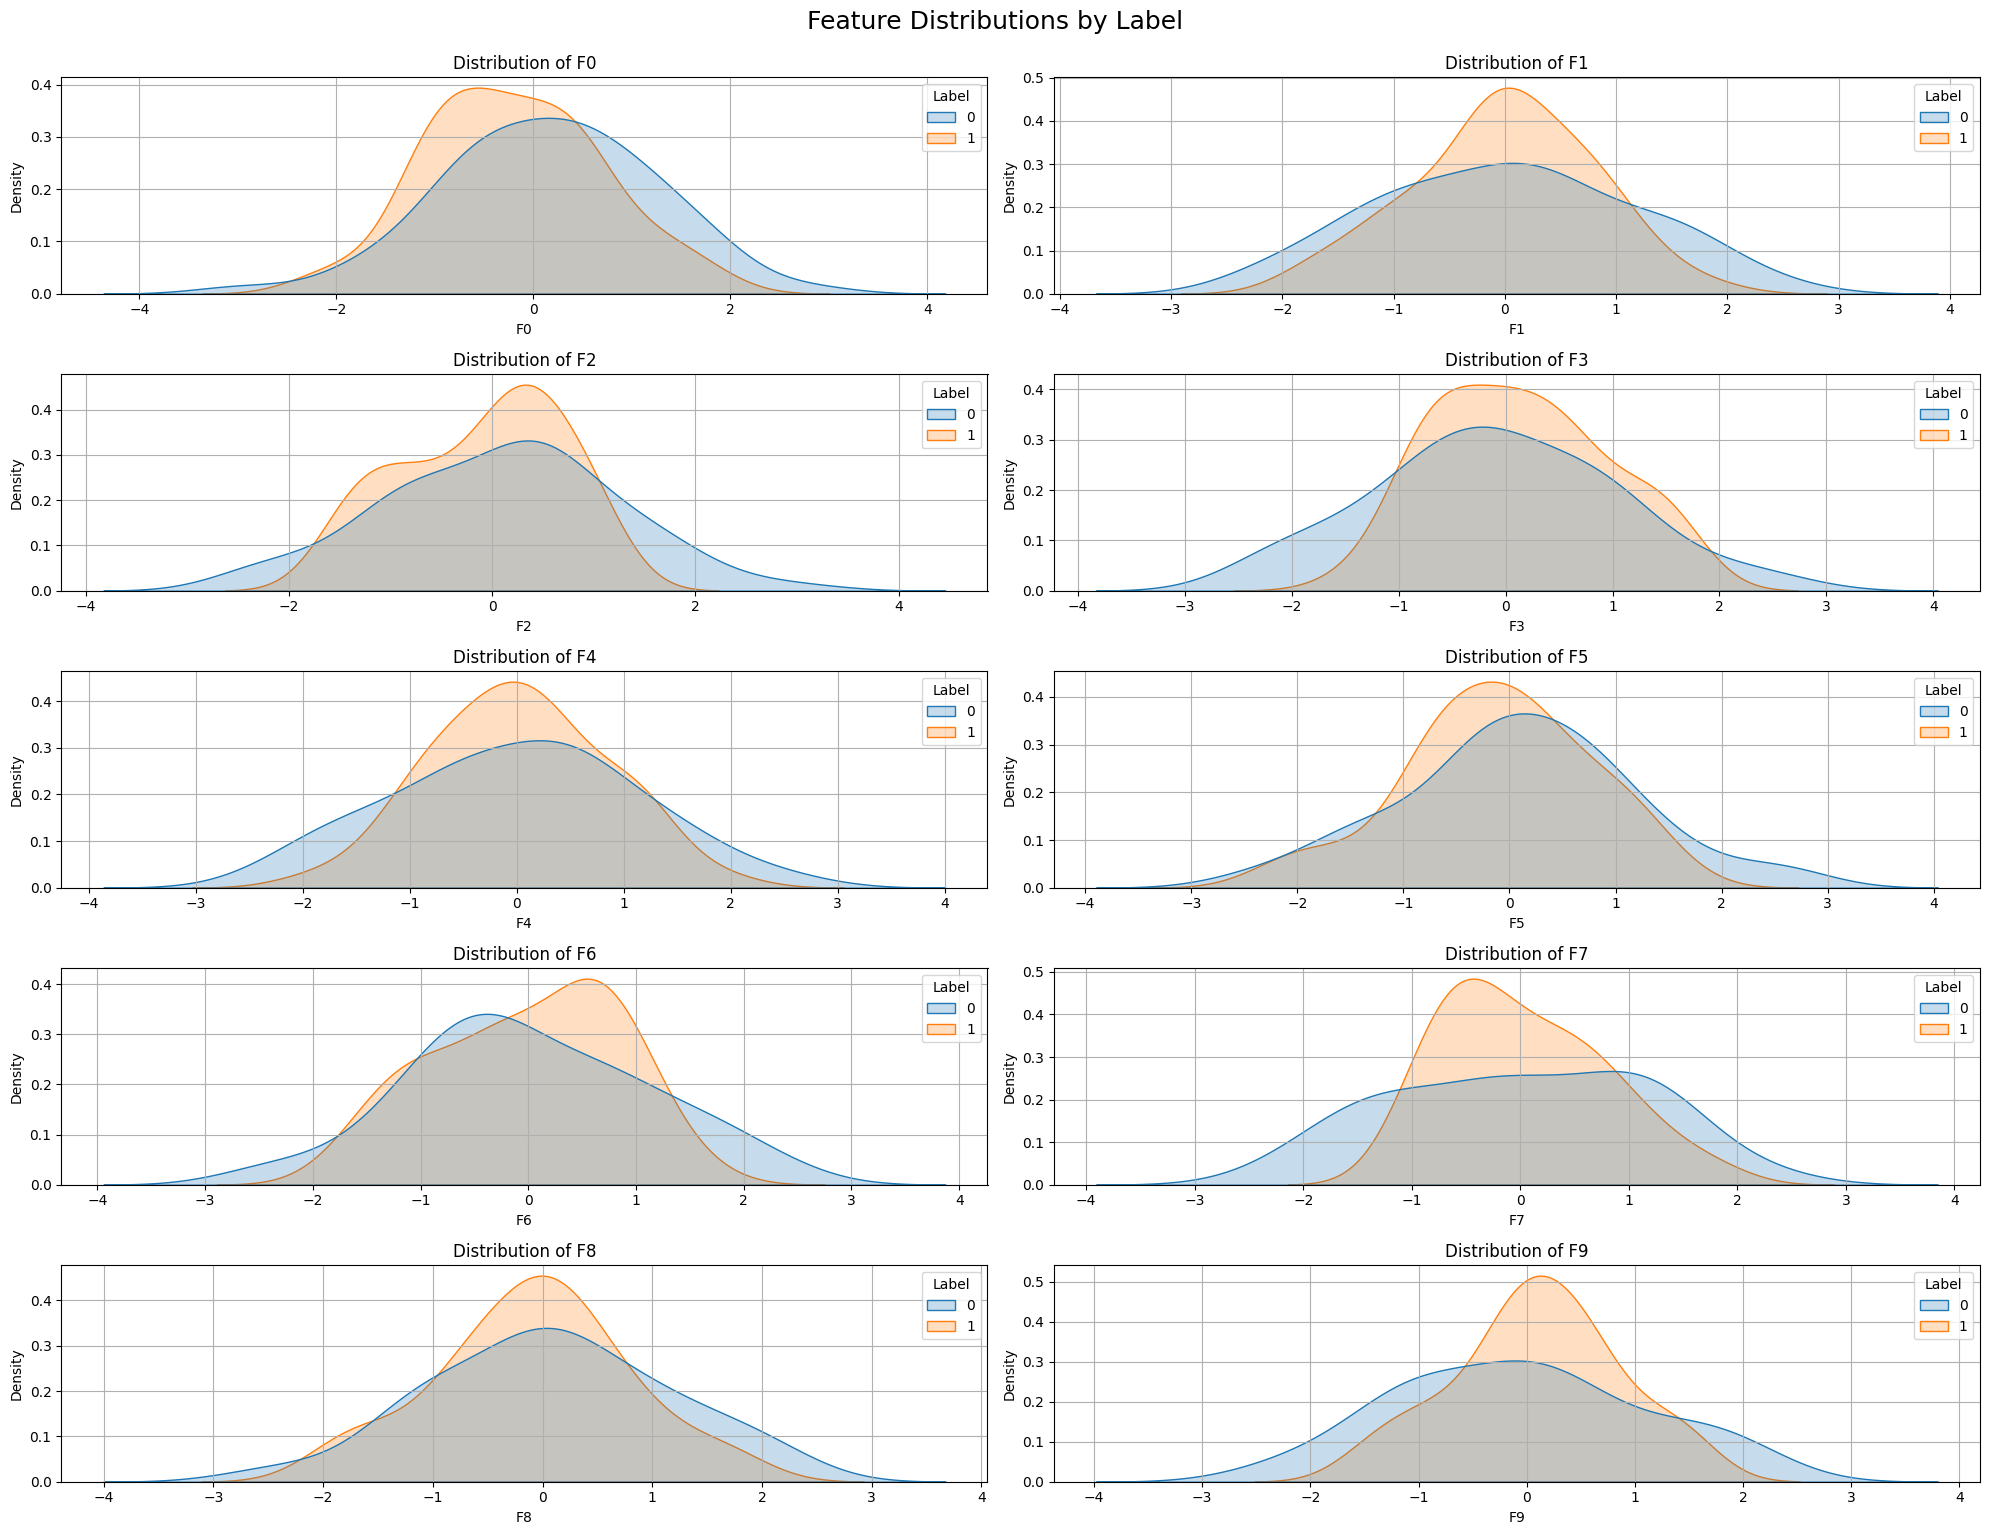

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
df_plot = df_power
# Ensure numeric conversion
df_plot = df_plot.apply(pd.to_numeric, errors='coerce')

# Select only numeric columns
numeric_cols = df_plot.select_dtypes(include=['number'])

# Plot the first N numeric features (change N as needed)
N = 10
features_to_plot = numeric_cols.columns[:N]  # ✅ Correct way to get first N columns

plt.figure(figsize=(20, 15))

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(5, 2, i)
    sns.kdeplot(data=df_plot, x=feature, hue="Label", common_norm=False, fill=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Feature Distributions by Label", fontsize=18, y=1.02)
plt.show()


# Feature Selection

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif


# Separate features and label
X = df_power.drop(columns=["Label"])
y = df_power["Label"]
combined_df  = df_power

# --- Technique 1: Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
rf_top_features = X.columns[np.argsort(rf.feature_importances_)[-15:]]

# --- Technique 2: Correlation ---
correlation = combined_df.corr()['Label'].drop('Label').abs()
corr_top_features = correlation.sort_values(ascending=False).head(15).index.tolist()

# --- Technique 3: ANOVA F-test ---
selector = SelectKBest(score_func=f_classif, k=15)
selector.fit(X, y)
anova_top_features = X.columns[selector.get_support()]

# --- Combine top features ---
combined_top_features = set(rf_top_features).union(corr_top_features).union(anova_top_features)

# Final selected features dataset
X_selected = X[list(combined_top_features)]
y_selected = y

# # Optional: Save to CSV
# X_selected.to_csv("selected_features.csv", index=False)
# y_selected.to_csv("selected_labels.csv", index=False)

print("New dataset created with top features. Shape:", X_selected.shape)


New dataset created with top features. Shape: (105, 10)


/opt/anaconda3/envs/pytorch/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=15 is greater than n_features=10. All the features will be returned.
  warnings.warn(


In [65]:
type(X_selected), type(y_selected), y_selected.shape, X_selected.shape

(pandas.core.frame.DataFrame, pandas.core.series.Series, (105,), (105, 23))

# ML Model


=== Random Forest (10-Fold CV with SMOTE on training only) ===
              precision    recall  f1-score   support

           0       0.76      0.70      0.73        60
           1       0.64      0.71      0.67        45

    accuracy                           0.70       105
   macro avg       0.70      0.71      0.70       105
weighted avg       0.71      0.70      0.71       105

Precision: 0.6400
Sensitivity (Recall): 0.7111
Specificity: 0.7000
F1 Score : 0.6737
Recall   : 0.7111
AUC Score: 0.7709


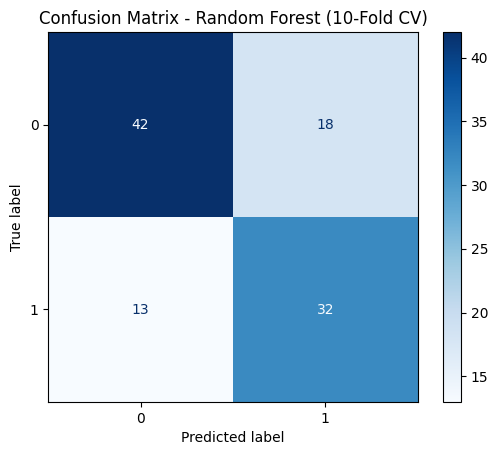

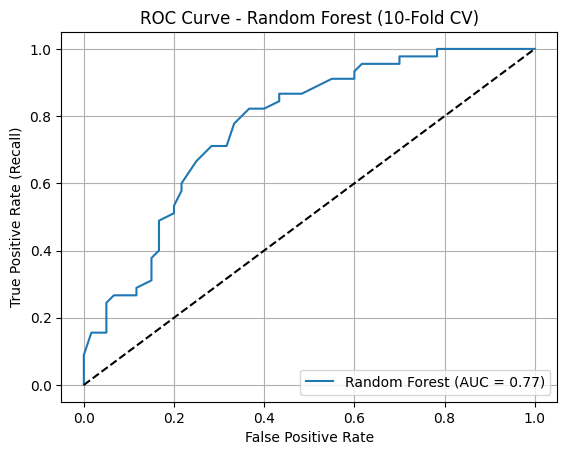


=== AdaBoost (10-Fold CV with SMOTE on training only) ===
              precision    recall  f1-score   support

           0       0.78      0.58      0.67        60
           1       0.58      0.78      0.67        45

    accuracy                           0.67       105
   macro avg       0.68      0.68      0.67       105
weighted avg       0.69      0.67      0.67       105

Precision: 0.5833
Sensitivity (Recall): 0.7778
Specificity: 0.5833
F1 Score : 0.6667
Recall   : 0.7778
AUC Score: 0.7835


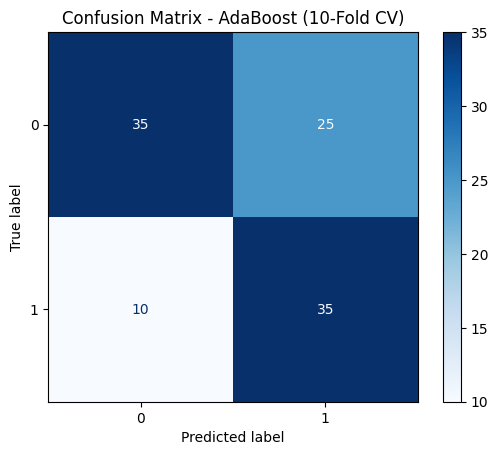

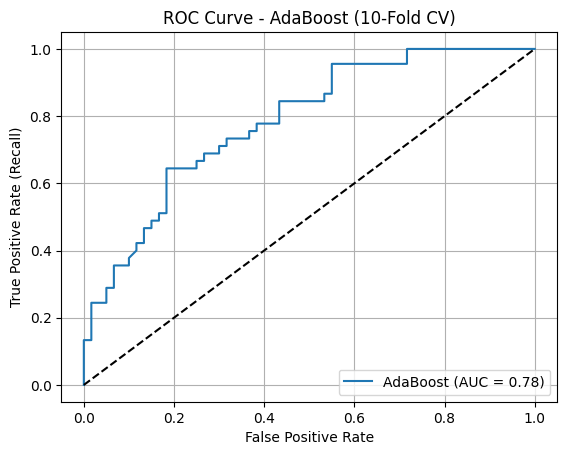


=== Gradient Boosting (10-Fold CV with SMOTE on training only) ===
              precision    recall  f1-score   support

           0       0.85      0.65      0.74        60
           1       0.64      0.84      0.73        45

    accuracy                           0.73       105
   macro avg       0.75      0.75      0.73       105
weighted avg       0.76      0.73      0.73       105

Precision: 0.6441
Sensitivity (Recall): 0.8444
Specificity: 0.6500
F1 Score : 0.7308
Recall   : 0.8444
AUC Score: 0.8041


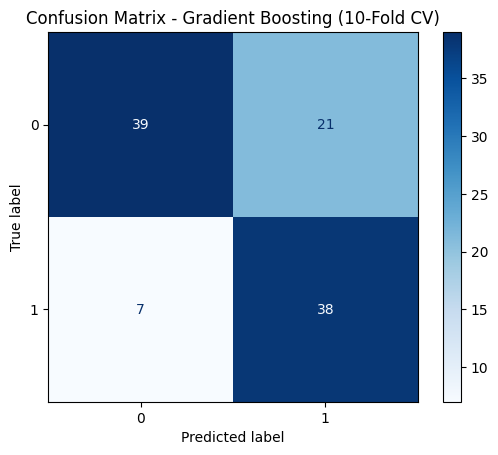

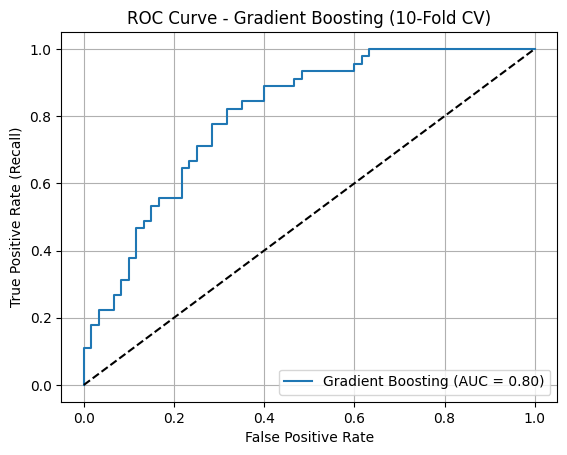


=== XGBoost (10-Fold CV with SMOTE on training only) ===


/opt/anaconda3/envs/pytorch/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [00:55:47] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/pytorch/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [00:55:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/pytorch/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [00:55:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/pytorch/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [00:55:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/envs/pytorch/lib/

              precision    recall  f1-score   support

           0       0.73      0.68      0.71        60
           1       0.61      0.67      0.64        45

    accuracy                           0.68       105
   macro avg       0.67      0.68      0.67       105
weighted avg       0.68      0.68      0.68       105

Precision: 0.6122
Sensitivity (Recall): 0.6667
Specificity: 0.6833
F1 Score : 0.6383
Recall   : 0.6667
AUC Score: 0.6467


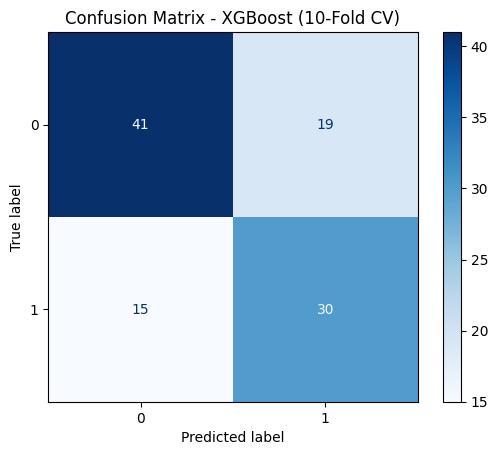

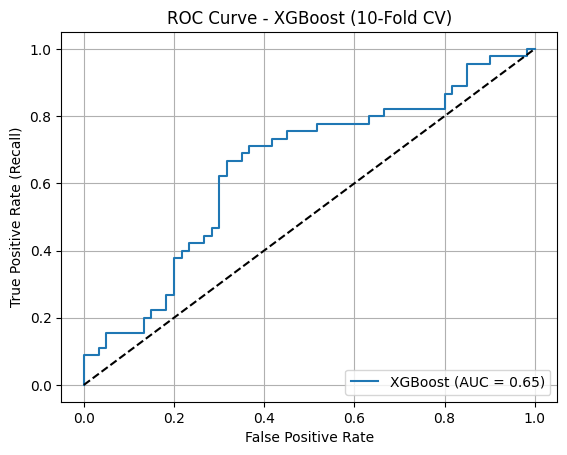


=== KNN (10-Fold CV with SMOTE on training only) ===
              precision    recall  f1-score   support

           0       0.50      0.02      0.03        60
           1       0.43      0.98      0.59        45

    accuracy                           0.43       105
   macro avg       0.46      0.50      0.31       105
weighted avg       0.47      0.43      0.27       105

Precision: 0.4272
Sensitivity (Recall): 0.9778
Specificity: 0.0167
F1 Score : 0.5946
Recall   : 0.9778
AUC Score: 0.6324


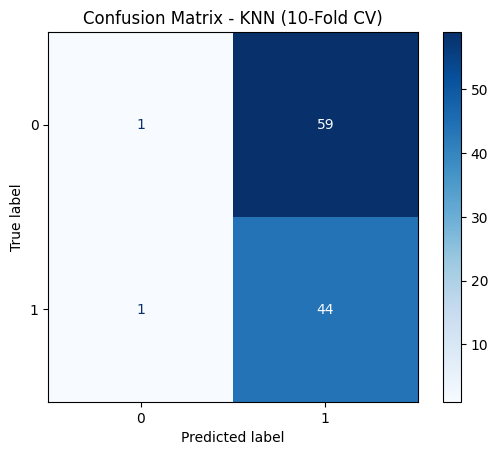

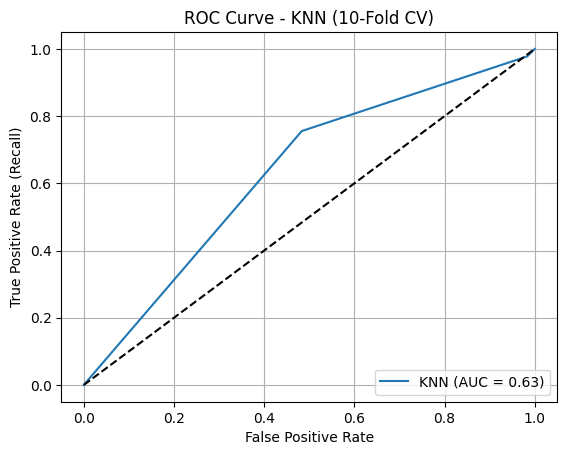

In [58]:
from sklearn.model_selection import StratifiedKFold

X_selected = df_power.drop(columns=["Label"])
y_selected = df_power["Label"]

# Define models
models = {
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "KNN": KNeighborsClassifier(),
}

# 10-Fold Stratified Cross-Validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n=== {name} (10-Fold CV with SMOTE on training only) ===")
    y_true, y_pred, y_proba = [], [], []

    for train_idx, test_idx in kf.split(X_selected, y_selected):
        X_train_orig, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
        y_train_orig, y_test = y_selected.iloc[train_idx], y_selected.iloc[test_idx]

        # Apply SMOTE only to training data
        smote = SMOTE(random_state=42)
        X_train, y_train = smote.fit_resample(X_train_orig, y_train_orig)

        # Train and predict
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        prob = model.predict_proba(X_test)[:, 1]

        y_true.extend(y_test)
        y_pred.extend(pred)
        y_proba.extend(prob)

    # Evaluation
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_proba = np.array(y_proba)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    auc = roc_auc_score(y_true, y_proba)
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    # Report
    print(classification_report(y_true, y_pred))
    print(f"Precision: {precision:.4f}")
    print(f"Sensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"F1 Score : {f1_score:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"AUC Score: {auc:.4f}")

    # Confusion Matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name} (10-Fold CV)")
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate (Recall)")
    plt.title(f"ROC Curve - {name} (10-Fold CV)")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


# SVM


=== SVM (10-Fold CV with SMOTE on training only) ===
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        60
           1       0.90      0.96      0.92        45

    accuracy                           0.93       105
   macro avg       0.93      0.94      0.93       105
weighted avg       0.94      0.93      0.93       105

Precision: 0.8958
Sensitivity (Recall): 0.9556
Specificity: 0.9167
F1 Score : 0.9247
Recall   : 0.9556
AUC Score: 0.9670


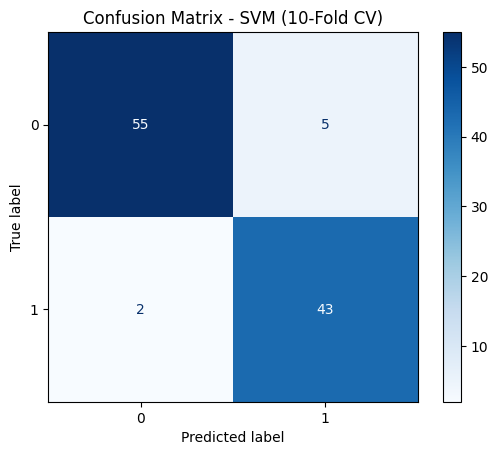

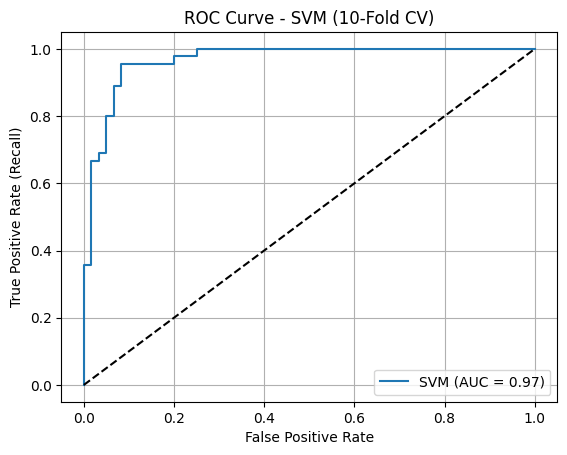

In [60]:
# without feature selection
# X_selected = combined_df.drop(columns=["Label"])
# y_selected = combined_df["Label"]
X_selected = df_power.drop(columns=["Label"])
y_selected = df_power["Label"]
# Step 1: Initialize Stratified 10-Fold CV
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Step 2: Define SVM model
model = SVC(probability=True, kernel='rbf', C=100, gamma='scale')

print("\n=== SVM (10-Fold CV with SMOTE on training only) ===")

y_true, y_pred, y_proba = [], [], []

for train_idx, test_idx in kf.split(X_selected, y_selected):
    # Split into train/test sets
    X_train_orig, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train_orig, y_test = y_selected.iloc[train_idx], y_selected.iloc[test_idx]

    # Apply SMOTE only on the training set
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train_orig, y_train_orig)

    # Train SVM on SMOTE-resampled data
    model.fit(X_train, y_train)

    # Predict on the original test set
    pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    else:
        decision_scores = model.decision_function(X_test)
        proba = (decision_scores - decision_scores.min()) / (decision_scores.max() - decision_scores.min())

    # Collect results
    y_true.extend(y_test)
    y_pred.extend(pred)
    y_proba.extend(proba)

# Convert results to arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_proba = np.array(y_proba)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
auc = roc_auc_score(y_true, y_proba)

precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    # Report
print(classification_report(y_true, y_pred))
print(f"Precision: {precision:.4f}")
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 Score : {f1_score:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"AUC Score: {auc:.4f}")

# Confusion Matrix Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM (10-Fold CV)")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_proba)
plt.plot(fpr, tpr, label=f"SVM (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - SVM (10-Fold CV)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


## standard deviations


=== SVM (10-Fold CV with SMOTE on training only) ===

Fold 1:
  Accuracy: 0.9091, Precision: 0.8333, Sensitivity: 1.0000, Specificity: 0.8333, F1: 0.9091, AUC: 0.9667

Fold 2:
  Accuracy: 1.0000, Precision: 1.0000, Sensitivity: 1.0000, Specificity: 1.0000, F1: 1.0000, AUC: 1.0000

Fold 3:
  Accuracy: 0.9091, Precision: 1.0000, Sensitivity: 0.8000, Specificity: 1.0000, F1: 0.8889, AUC: 1.0000

Fold 4:
  Accuracy: 1.0000, Precision: 1.0000, Sensitivity: 1.0000, Specificity: 1.0000, F1: 1.0000, AUC: 1.0000

Fold 5:
  Accuracy: 1.0000, Precision: 1.0000, Sensitivity: 1.0000, Specificity: 1.0000, F1: 1.0000, AUC: 1.0000

Fold 6:
  Accuracy: 0.8000, Precision: 0.6667, Sensitivity: 1.0000, Specificity: 0.6667, F1: 0.8000, AUC: 0.8750

Fold 7:
  Accuracy: 1.0000, Precision: 1.0000, Sensitivity: 1.0000, Specificity: 1.0000, F1: 1.0000, AUC: 1.0000

Fold 8:
  Accuracy: 1.0000, Precision: 1.0000, Sensitivity: 1.0000, Specificity: 1.0000, F1: 1.0000, AUC: 1.0000

Fold 9:
  Accuracy: 0.8000, Preci

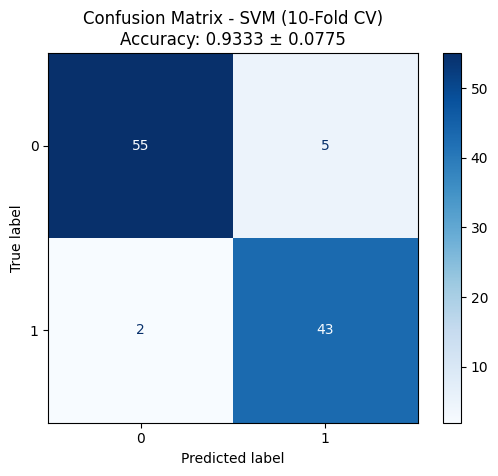

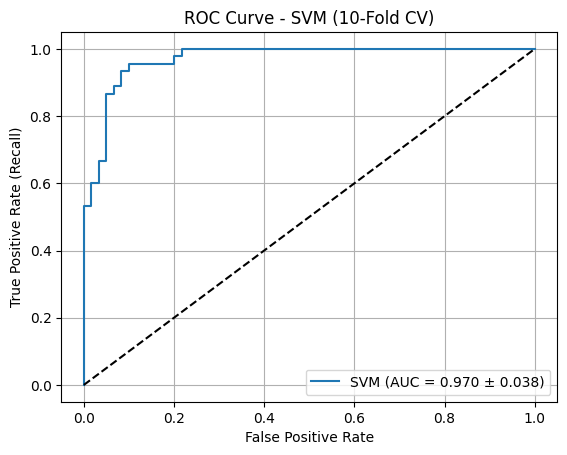

/tmp/ipykernel_27737/764928319.py:176: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=[m.capitalize() for m in metrics_to_plot], patch_artist=True)


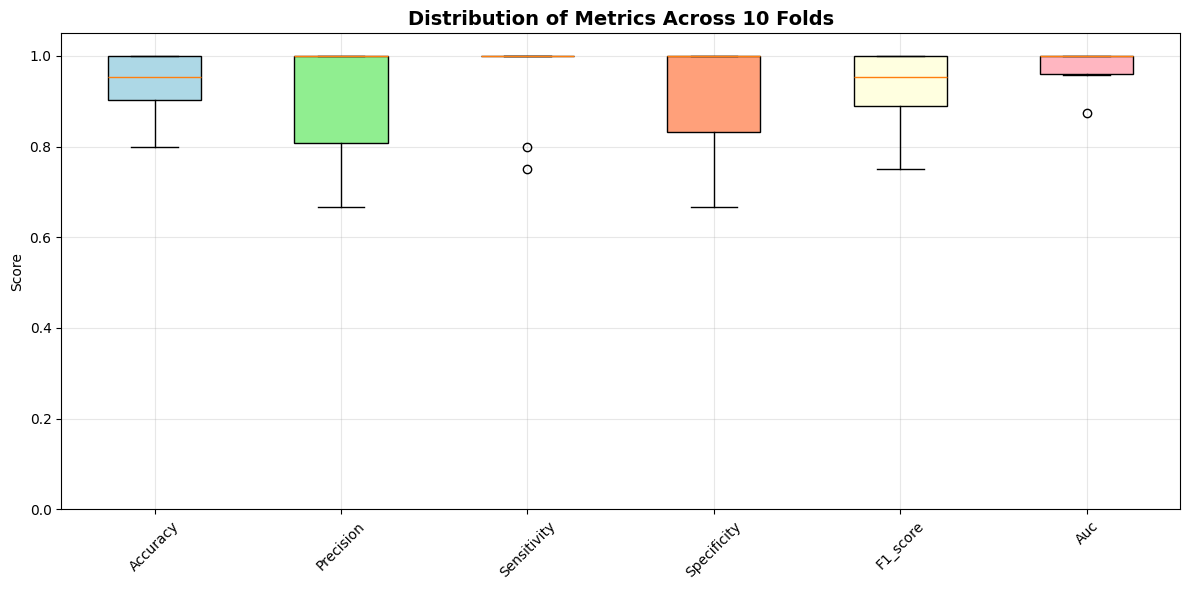

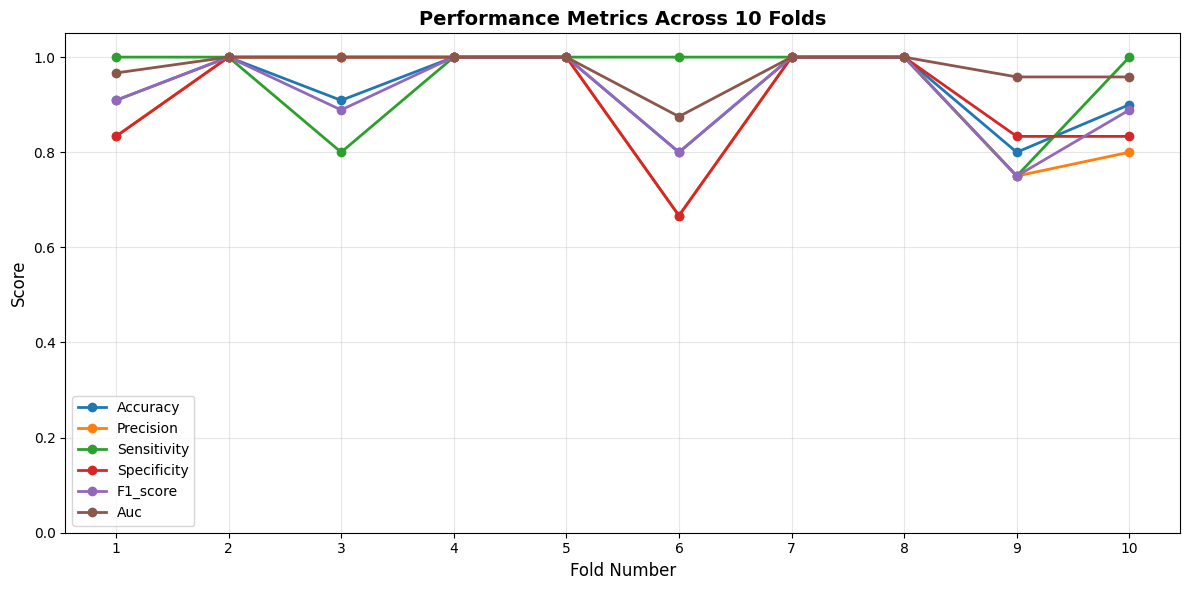

In [65]:
# without feature selection
# X_selected = combined_df.drop(columns=["Label"])
# y_selected = combined_df["Label"]
X_selected = df_power.drop(columns=["Label"])
y_selected = df_power["Label"]

# Step 1: Initialize Stratified 10-Fold CV
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Step 2: Define SVM model
model = SVC(probability=True, kernel='rbf', C=100, gamma='scale')

print("\n=== SVM (10-Fold CV with SMOTE on training only) ===")

# Store metrics for each fold
fold_metrics = {
    'accuracy': [],
    'precision': [],
    'sensitivity': [],
    'specificity': [],
    'f1_score': [],
    'recall': [],
    'auc': []
}

y_true_all = []
y_pred_all = []
y_proba_all = []

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_selected, y_selected), 1):
    # Split into train/test sets
    X_train_orig, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train_orig, y_test = y_selected.iloc[train_idx], y_selected.iloc[test_idx]

    # Apply SMOTE only on the training set
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train_orig, y_train_orig)

    # Train SVM on SMOTE-resampled data
    model.fit(X_train, y_train)

    # Predict on the original test set
    pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    else:
        decision_scores = model.decision_function(X_test)
        proba = (decision_scores - decision_scores.min()) / (decision_scores.max() - decision_scores.min())

    # Calculate metrics for this fold
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    
    fold_accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
    fold_sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fold_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fold_precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    fold_recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fold_f1 = 2 * (fold_precision * fold_recall) / (fold_precision + fold_recall) if (fold_precision + fold_recall) > 0 else 0.0
    fold_auc = roc_auc_score(y_test, proba)
    
    # Store fold metrics
    fold_metrics['accuracy'].append(fold_accuracy)
    fold_metrics['precision'].append(fold_precision)
    fold_metrics['sensitivity'].append(fold_sensitivity)
    fold_metrics['specificity'].append(fold_specificity)
    fold_metrics['f1_score'].append(fold_f1)
    fold_metrics['recall'].append(fold_recall)
    fold_metrics['auc'].append(fold_auc)
    
    # Collect all results for overall confusion matrix
    y_true_all.extend(y_test)
    y_pred_all.extend(pred)
    y_proba_all.extend(proba)
    
    # Print fold results
    print(f"\nFold {fold_idx}:")
    print(f"  Accuracy: {fold_accuracy:.4f}, Precision: {fold_precision:.4f}, "
          f"Sensitivity: {fold_sensitivity:.4f}, Specificity: {fold_specificity:.4f}, "
          f"F1: {fold_f1:.4f}, AUC: {fold_auc:.4f}")

# Convert results to arrays for overall metrics
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)
y_proba_all = np.array(y_proba_all)

# Calculate overall metrics (aggregated across all folds)
overall_cm = confusion_matrix(y_true_all, y_pred_all)
tn, fp, fn, tp = overall_cm.ravel()
overall_accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
overall_sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
overall_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
overall_precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
overall_recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
overall_f1 = 2 * (overall_precision * overall_recall) / (overall_precision + overall_recall) if (overall_precision + overall_recall) > 0 else 0.0
overall_auc = roc_auc_score(y_true_all, y_proba_all)

# Calculate mean and standard deviation for each metric
print("\n" + "="*70)
print("FINAL RESULTS - 10-FOLD CROSS-VALIDATION")
print("="*70)
print(f"{'Metric':<15} {'Mean':<10} {'Std Dev':<10} {'Overall':<10}")
print("-"*70)

metrics_names = {
    'accuracy': 'Accuracy',
    'precision': 'Precision',
    'sensitivity': 'Sensitivity',
    'specificity': 'Specificity',
    'f1_score': 'F1 Score',
    'recall': 'Recall',
    'auc': 'AUC'
}

for metric_key, metric_name in metrics_names.items():
    mean_val = np.mean(fold_metrics[metric_key])
    std_val = np.std(fold_metrics[metric_key])
    
    # Get overall value
    if metric_key == 'accuracy':
        overall_val = overall_accuracy
    elif metric_key == 'precision':
        overall_val = overall_precision
    elif metric_key == 'sensitivity':
        overall_val = overall_sensitivity
    elif metric_key == 'specificity':
        overall_val = overall_specificity
    elif metric_key == 'f1_score':
        overall_val = overall_f1
    elif metric_key == 'recall':
        overall_val = overall_recall
    elif metric_key == 'auc':
        overall_val = overall_auc
    
    print(f"{metric_name:<15} {mean_val:.4f}     {std_val:.4f}     {overall_val:.4f}")

print("="*70)

# Print summary statistics for all metrics
print("\n" + "-"*70)
print("SUMMARY STATISTICS ACROSS 10 FOLDS:")
print("-"*70)
for metric_key, metric_name in metrics_names.items():
    mean_val = np.mean(fold_metrics[metric_key])
    std_val = np.std(fold_metrics[metric_key])
    min_val = np.min(fold_metrics[metric_key])
    max_val = np.max(fold_metrics[metric_key])
    print(f"{metric_name:12} | Mean: {mean_val:.4f} | Std: {std_val:.4f} | Min: {min_val:.4f} | Max: {max_val:.4f}")

# Print detailed classification report for overall predictions
print("\nClassification Report (Overall):")
print(classification_report(y_true_all, y_pred_all))

# Confusion Matrix Plot
disp = ConfusionMatrixDisplay(confusion_matrix=overall_cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - SVM (10-Fold CV)\nAccuracy: {overall_accuracy:.4f} ± {np.std(fold_metrics['accuracy']):.4f}")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true_all, y_proba_all)
plt.plot(fpr, tpr, label=f"SVM (AUC = {overall_auc:.3f} ± {np.std(fold_metrics['auc']):.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - SVM (10-Fold CV)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Box plot to visualize distribution of metrics across folds
fig, ax = plt.subplots(figsize=(12, 6))
metrics_to_plot = ['accuracy', 'precision', 'sensitivity', 'specificity', 'f1_score', 'auc']
data_to_plot = [fold_metrics[m] for m in metrics_to_plot]
bp = ax.boxplot(data_to_plot, labels=[m.capitalize() for m in metrics_to_plot], patch_artist=True)

# Customize boxplot colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightsalmon', 'lightyellow', 'lightpink']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Score')
ax.set_title('Distribution of Metrics Across 10 Folds', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Optional: Line plot showing metric trends across folds
fig, ax = plt.subplots(figsize=(12, 6))
folds = range(1, 11)
for metric_key in metrics_to_plot:
    ax.plot(folds, fold_metrics[metric_key], marker='o', label=metric_key.capitalize(), linewidth=2)
ax.set_xlabel('Fold Number', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Metrics Across 10 Folds', fontsize=14, fontweight='bold')
ax.set_xticks(folds)
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

## Confidence_interval


=== SVM (10-Fold CV with SMOTE on training only) ===

Fold 1:
  Accuracy: 0.9091, Precision: 0.8333, Sensitivity: 1.0000, Specificity: 0.8333, F1: 0.9091, AUC: 0.9667

Fold 2:
  Accuracy: 1.0000, Precision: 1.0000, Sensitivity: 1.0000, Specificity: 1.0000, F1: 1.0000, AUC: 1.0000

Fold 3:
  Accuracy: 0.9091, Precision: 1.0000, Sensitivity: 0.8000, Specificity: 1.0000, F1: 0.8889, AUC: 1.0000

Fold 4:
  Accuracy: 1.0000, Precision: 1.0000, Sensitivity: 1.0000, Specificity: 1.0000, F1: 1.0000, AUC: 1.0000

Fold 5:
  Accuracy: 1.0000, Precision: 1.0000, Sensitivity: 1.0000, Specificity: 1.0000, F1: 1.0000, AUC: 1.0000

Fold 6:
  Accuracy: 0.8000, Precision: 0.6667, Sensitivity: 1.0000, Specificity: 0.6667, F1: 0.8000, AUC: 0.9167

Fold 7:
  Accuracy: 0.9000, Precision: 0.8000, Sensitivity: 1.0000, Specificity: 0.8333, F1: 0.8889, AUC: 1.0000

Fold 8:
  Accuracy: 1.0000, Precision: 1.0000, Sensitivity: 1.0000, Specificity: 1.0000, F1: 1.0000, AUC: 1.0000

Fold 9:
  Accuracy: 0.9000, Preci

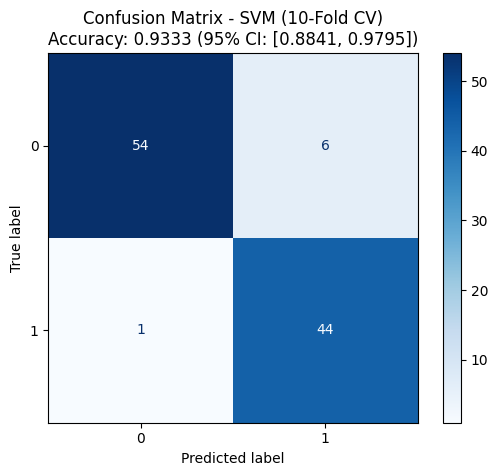

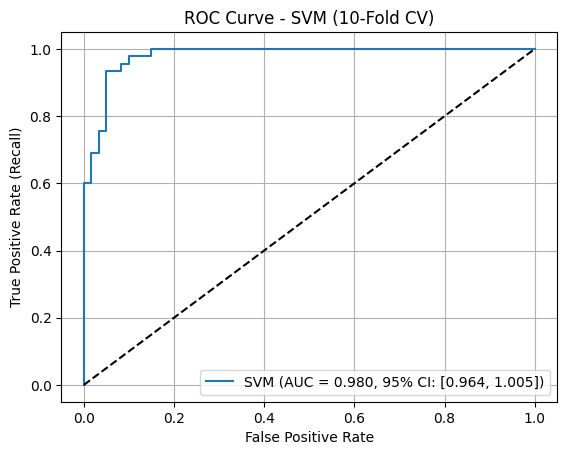

/tmp/ipykernel_27737/265920564.py:214: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=[m.capitalize() for m in metrics_to_plot], patch_artist=True)


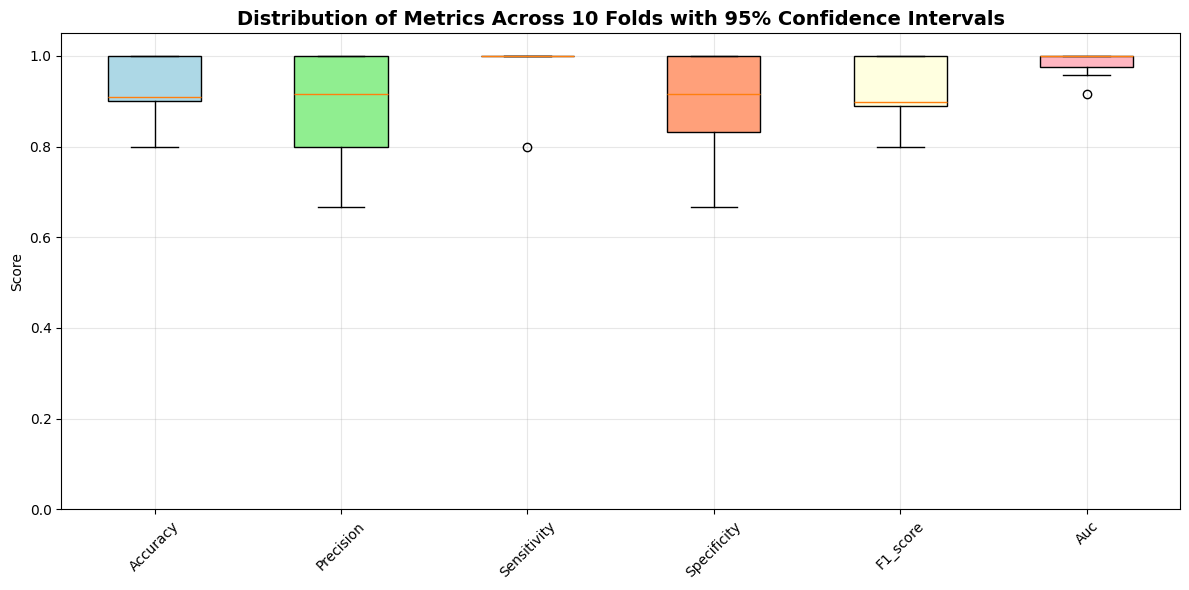

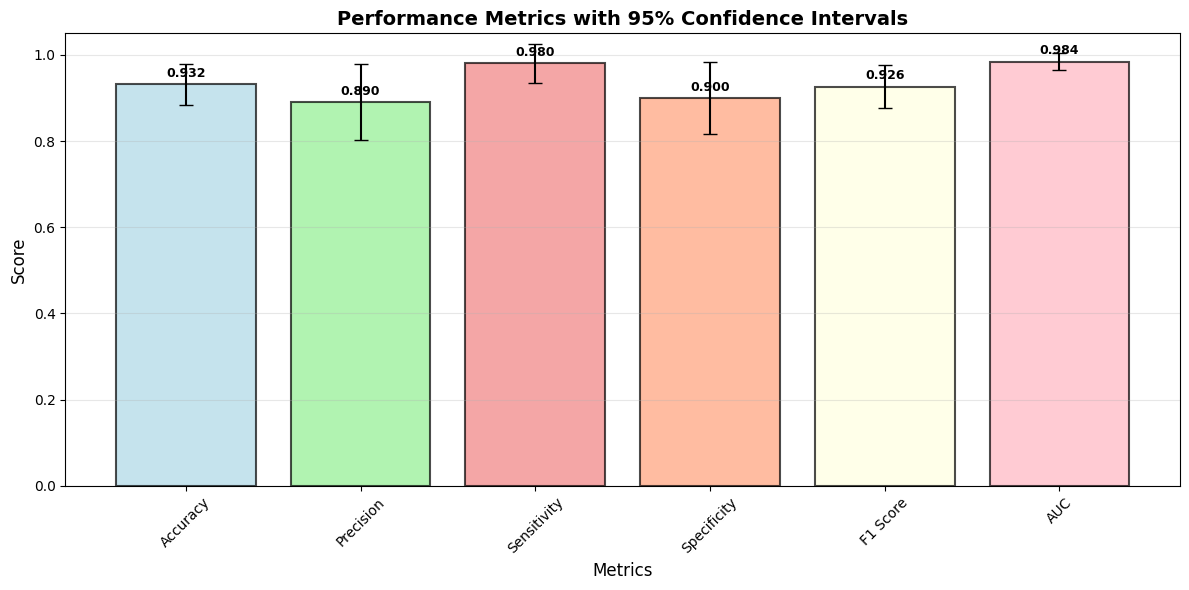

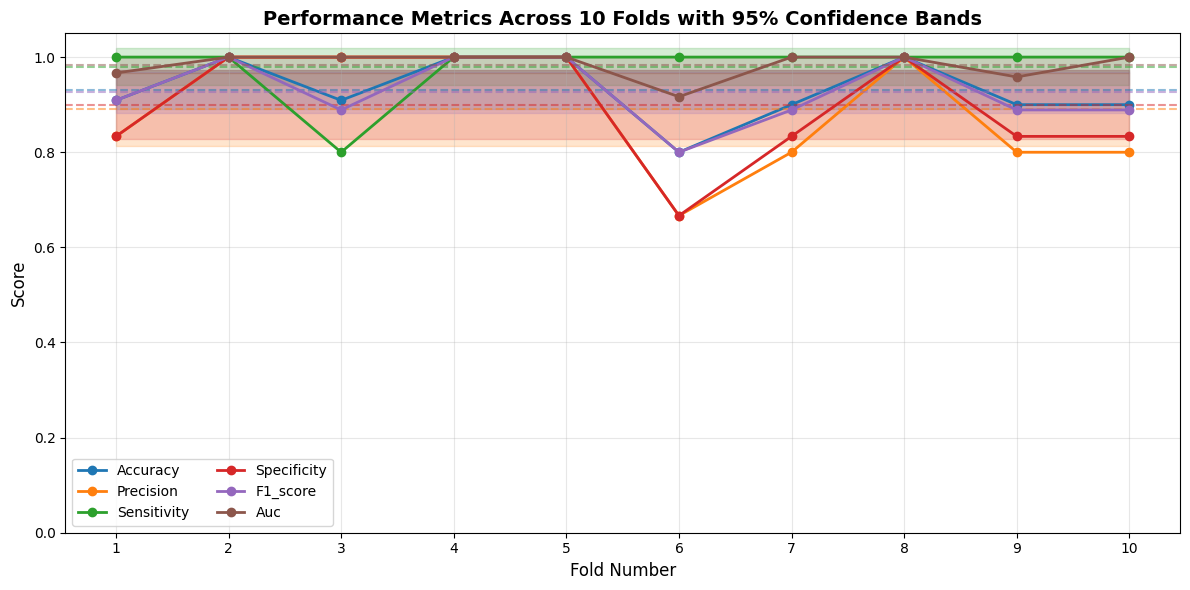


SUMMARY TABLE WITH CONFIDENCE INTERVALS:
     Metric     Mean  Std Dev  CI Lower (95%)  CI Upper (95%)  CI Width  Overall
   Accuracy 0.931818 0.063278        0.884103        0.979533  0.095430 0.933333
  Precision 0.890000 0.117426        0.801455        0.978545  0.177091 0.880000
Sensitivity 0.980000 0.060000        0.934757        1.025243  0.090486 0.977778
Specificity 0.900000 0.110554        0.816636        0.983364  0.166727 0.900000
   F1 Score 0.926465 0.066010        0.876690        0.976239  0.099549 0.926316
     Recall 0.980000 0.060000        0.934757        1.025243  0.090486 0.977778
        AUC 0.984167 0.026990        0.963815        1.004519  0.040704 0.980000


In [78]:
from scipy import stats 
# without feature selection
# X_selected = combined_df.drop(columns=["Label"])
# y_selected = combined_df["Label"]
X_selected = df_power.drop(columns=["Label"])
y_selected = df_power["Label"]

# Step 1: Initialize Stratified 10-Fold CV
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Step 2: Define SVM model
model = SVC(probability=True, kernel='rbf', C=1.0, gamma='scale')

print("\n=== SVM (10-Fold CV with SMOTE on training only) ===")

# Store metrics for each fold
fold_metrics = {
    'accuracy': [],
    'precision': [],
    'sensitivity': [],
    'specificity': [],
    'f1_score': [],
    'recall': [],
    'auc': []
}

y_true_all = []
y_pred_all = []
y_proba_all = []

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_selected, y_selected), 1):
    # Split into train/test sets
    X_train_orig, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train_orig, y_test = y_selected.iloc[train_idx], y_selected.iloc[test_idx]

    # Apply SMOTE only on the training set
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train_orig, y_train_orig)

    # Train SVM on SMOTE-resampled data
    model.fit(X_train, y_train)

    # Predict on the original test set
    pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    else:
        decision_scores = model.decision_function(X_test)
        proba = (decision_scores - decision_scores.min()) / (decision_scores.max() - decision_scores.min())

    # Calculate metrics for this fold
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    
    fold_accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
    fold_sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fold_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fold_precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    fold_recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fold_f1 = 2 * (fold_precision * fold_recall) / (fold_precision + fold_recall) if (fold_precision + fold_recall) > 0 else 0.0
    fold_auc = roc_auc_score(y_test, proba)
    
    # Store fold metrics
    fold_metrics['accuracy'].append(fold_accuracy)
    fold_metrics['precision'].append(fold_precision)
    fold_metrics['sensitivity'].append(fold_sensitivity)
    fold_metrics['specificity'].append(fold_specificity)
    fold_metrics['f1_score'].append(fold_f1)
    fold_metrics['recall'].append(fold_recall)
    fold_metrics['auc'].append(fold_auc)
    
    # Collect all results for overall confusion matrix
    y_true_all.extend(y_test)
    y_pred_all.extend(pred)
    y_proba_all.extend(proba)
    
    # Print fold results
    print(f"\nFold {fold_idx}:")
    print(f"  Accuracy: {fold_accuracy:.4f}, Precision: {fold_precision:.4f}, "
          f"Sensitivity: {fold_sensitivity:.4f}, Specificity: {fold_specificity:.4f}, "
          f"F1: {fold_f1:.4f}, AUC: {fold_auc:.4f}")

# Convert results to arrays for overall metrics
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)
y_proba_all = np.array(y_proba_all)

# Calculate overall metrics (aggregated across all folds)
overall_cm = confusion_matrix(y_true_all, y_pred_all)
tn, fp, fn, tp = overall_cm.ravel()
overall_accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
overall_sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
overall_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
overall_precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
overall_recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
overall_f1 = 2 * (overall_precision * overall_recall) / (overall_precision + overall_recall) if (overall_precision + overall_recall) > 0 else 0.0
overall_auc = roc_auc_score(y_true_all, y_proba_all)

# Function to calculate confidence intervals
def calculate_confidence_interval(data, confidence=0.95):
    """
    Calculate confidence interval for a list of values
    Returns: (mean, lower_bound, upper_bound)
    """
    n = len(data)
    mean = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(n)  # Standard error
    ci_range = std_err * stats.t.ppf((1 + confidence) / 2, n - 1)
    lower_bound = mean - ci_range
    upper_bound = mean + ci_range
    return mean, lower_bound, upper_bound

# Calculate mean, std, and confidence intervals for each metric
print("\n" + "="*80)
print("FINAL RESULTS - 10-FOLD CROSS-VALIDATION WITH 95% CONFIDENCE INTERVALS")
print("="*80)
print(f"{'Metric':<15} {'Mean':<10} {'Std Dev':<10} {'95% CI Lower':<12} {'95% CI Upper':<12} {'Overall':<10}")
print("-"*80)

metrics_names = {
    'accuracy': 'Accuracy',
    'precision': 'Precision',
    'sensitivity': 'Sensitivity',
    'specificity': 'Specificity',
    'f1_score': 'F1 Score',
    'recall': 'Recall',
    'auc': 'AUC'
}

# Store confidence intervals for later use
confidence_intervals = {}

for metric_key, metric_name in metrics_names.items():
    mean_val = np.mean(fold_metrics[metric_key])
    std_val = np.std(fold_metrics[metric_key])
    
    # Calculate 95% confidence interval
    ci_mean, ci_lower, ci_upper = calculate_confidence_interval(fold_metrics[metric_key], confidence=0.95)
    confidence_intervals[metric_key] = (ci_lower, ci_upper)
    
    # Get overall value
    if metric_key == 'accuracy':
        overall_val = overall_accuracy
    elif metric_key == 'precision':
        overall_val = overall_precision
    elif metric_key == 'sensitivity':
        overall_val = overall_sensitivity
    elif metric_key == 'specificity':
        overall_val = overall_specificity
    elif metric_key == 'f1_score':
        overall_val = overall_f1
    elif metric_key == 'recall':
        overall_val = overall_recall
    elif metric_key == 'auc':
        overall_val = overall_auc
    
    print(f"{metric_name:<15} {mean_val:.4f}     {std_val:.4f}     "
          f"{ci_lower:.4f}        {ci_upper:.4f}       {overall_val:.4f}")

print("="*80)

# Print summary statistics with confidence intervals
print("\n" + "-"*80)
print("SUMMARY STATISTICS ACROSS 10 FOLDS WITH 95% CONFIDENCE INTERVALS:")
print("-"*80)
for metric_key, metric_name in metrics_names.items():
    mean_val = np.mean(fold_metrics[metric_key])
    std_val = np.std(fold_metrics[metric_key])
    min_val = np.min(fold_metrics[metric_key])
    max_val = np.max(fold_metrics[metric_key])
    ci_lower, ci_upper = confidence_intervals[metric_key]
    print(f"{metric_name:12} | Mean: {mean_val:.4f} | Std: {std_val:.4f} | "
          f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}] | Range: [{min_val:.4f}, {max_val:.4f}]")

# Calculate and display confidence interval width for each metric
print("\n" + "-"*80)
print("CONFIDENCE INTERVAL WIDTHS (Measure of Uncertainty):")
print("-"*80)
for metric_key, metric_name in metrics_names.items():
    ci_lower, ci_upper = confidence_intervals[metric_key]
    ci_width = ci_upper - ci_lower
    relative_width = (ci_width / np.mean(fold_metrics[metric_key])) * 100
    print(f"{metric_name:12} | CI Width: {ci_width:.4f} | Relative Width: {relative_width:.2f}%")

# Print detailed classification report for overall predictions
print("\nClassification Report (Overall):")
print(classification_report(y_true_all, y_pred_all))

# Confusion Matrix Plot with confidence interval in title
disp = ConfusionMatrixDisplay(confusion_matrix=overall_cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
ci_acc_lower, ci_acc_upper = confidence_intervals['accuracy']
plt.title(f"Confusion Matrix - SVM (10-Fold CV)\n"
          f"Accuracy: {overall_accuracy:.4f} (95% CI: [{ci_acc_lower:.4f}, {ci_acc_upper:.4f}])")
plt.show()

# ROC Curve with AUC confidence interval
fpr, tpr, thresholds = roc_curve(y_true_all, y_proba_all)
ci_auc_lower, ci_auc_upper = confidence_intervals['auc']
plt.plot(fpr, tpr, label=f"SVM (AUC = {overall_auc:.3f}, 95% CI: [{ci_auc_lower:.3f}, {ci_auc_upper:.3f}])")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - SVM (10-Fold CV)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Box plot to visualize distribution of metrics across folds
fig, ax = plt.subplots(figsize=(12, 6))
metrics_to_plot = ['accuracy', 'precision', 'sensitivity', 'specificity', 'f1_score', 'auc']
data_to_plot = [fold_metrics[m] for m in metrics_to_plot]
bp = ax.boxplot(data_to_plot, labels=[m.capitalize() for m in metrics_to_plot], patch_artist=True)

# Customize boxplot colors
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightsalmon', 'lightyellow', 'lightpink']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Score')
ax.set_title('Distribution of Metrics Across 10 Folds with 95% Confidence Intervals', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Bar plot with error bars (confidence intervals)
fig, ax = plt.subplots(figsize=(12, 6))
metric_names_list = [metrics_names[m] for m in metrics_to_plot]
means = [np.mean(fold_metrics[m]) for m in metrics_to_plot]
ci_lowers = [confidence_intervals[m][0] for m in metrics_to_plot]
ci_uppers = [confidence_intervals[m][1] for m in metrics_to_plot]
errors = [[means[i] - ci_lowers[i] for i in range(len(means))], 
          [ci_uppers[i] - means[i] for i in range(len(means))]]

x_pos = np.arange(len(metric_names_list))
bars = ax.bar(x_pos, means, yerr=errors, capsize=5, alpha=0.7, 
              color=['lightblue', 'lightgreen', 'lightcoral', 'lightsalmon', 'lightyellow', 'lightpink'],
              edgecolor='black', linewidth=1.5)

ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Metrics', fontsize=12)
ax.set_title('Performance Metrics with 95% Confidence Intervals', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(metric_names_list, rotation=45)
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, mean_val) in enumerate(zip(bars, means)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{mean_val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Line plot showing metric trends across folds with confidence band
fig, ax = plt.subplots(figsize=(12, 6))
folds = range(1, 11)
for metric_key in metrics_to_plot:
    ax.plot(folds, fold_metrics[metric_key], marker='o', label=metric_key.capitalize(), linewidth=2)
    
    # Add confidence band (using standard error across folds)
    mean_val = np.mean(fold_metrics[metric_key])
    std_err = np.std(fold_metrics[metric_key], ddof=1) / np.sqrt(len(folds))
    ax.axhline(y=mean_val, linestyle='--', alpha=0.5, color=ax.lines[-1].get_color())
    ax.fill_between(folds, mean_val - 1.96*std_err, mean_val + 1.96*std_err, 
                    alpha=0.2, color=ax.lines[-1].get_color())

ax.set_xlabel('Fold Number', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Metrics Across 10 Folds with 95% Confidence Bands', fontsize=14, fontweight='bold')
ax.set_xticks(folds)
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)
ax.legend(loc='best', ncol=2)
plt.tight_layout()
plt.show()

# Optional: Create a summary DataFrame with confidence intervals
summary_df = pd.DataFrame({
    'Metric': [metrics_names[m] for m in metrics_names.keys()],
    'Mean': [np.mean(fold_metrics[m]) for m in metrics_names.keys()],
    'Std Dev': [np.std(fold_metrics[m]) for m in metrics_names.keys()],
    'CI Lower (95%)': [confidence_intervals[m][0] for m in metrics_names.keys()],
    'CI Upper (95%)': [confidence_intervals[m][1] for m in metrics_names.keys()],
    'CI Width': [confidence_intervals[m][1] - confidence_intervals[m][0] for m in metrics_names.keys()],
    'Overall': [overall_accuracy if m=='accuracy' else 
                overall_precision if m=='precision' else
                overall_sensitivity if m=='sensitivity' else
                overall_specificity if m=='specificity' else
                overall_f1 if m=='f1_score' else
                overall_recall if m=='recall' else
                overall_auc for m in metrics_names.keys()]
})

print("\n" + "="*80)
print("SUMMARY TABLE WITH CONFIDENCE INTERVALS:")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)

# Grid Search SVM

In [55]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
# without feature selection
# X_selected = combined_df.drop(columns=["Label"])
# y_selected = combined_df["Label"]

X_selected = df_real.drop(columns=["Label"])
y_selected = df_real["Label"]

# Step 1: Define 10-Fold cross-validator
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Step 2: Define base SVM model and parameter grid
base_model = SVC(probability=True)
param_grid = {
    'C': [10, 20, 50, 100],
    'gamma': [0.01, 0.1],
    'kernel': ['poly', 'rbf'],
    'degree': [3, 4]  # Only relevant for 'poly'
}

print(f"\n=== SVM with GridSearch + SMOTE (10-Fold CV) ===")

y_true, y_pred, y_proba = [], [], []

for train_idx, test_idx in kf.split(X_selected, y_selected):
    X_train_orig, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train_orig, y_test = y_selected.iloc[train_idx], y_selected.iloc[test_idx]

    # Apply SMOTE on training data only
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train_orig, y_train_orig)

    # Grid Search
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring='accuracy',
        cv=5,
        n_jobs=-1,
        verbose=0
    )
    grid_search.fit(X_train, y_train)
    model = grid_search.best_estimator_

    # Predict on real test sample
    prediction = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    else:
        decision_scores = model.decision_function(X_test)
        proba = (decision_scores - decision_scores.min()) / (decision_scores.max() - decision_scores.min())

    y_true.extend(y_test)
    y_pred.extend(prediction)
    y_proba.extend(proba)

# Step 4: Evaluation
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_proba = np.array(y_proba)

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
auc = roc_auc_score(y_true, y_proba)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    # Report
print(classification_report(y_true, y_pred))
print(f"Precision: {precision:.4f}")
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 Score : {f1_score:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"AUC Score: {auc:.4f}")


# Confusion Matrix Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM (10-Fold CV with GridSearch + SMOTE)")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_proba)
plt.plot(fpr, tpr, label=f"SVM (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - SVM (10-Fold CV with GridSearch + SMOTE)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



=== SVM with GridSearch + SMOTE (10-Fold CV) ===


KeyboardInterrupt: 

# MLP


Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.68      0.66        60
           1       0.53      0.47      0.49        45

    accuracy                           0.59       105
   macro avg       0.58      0.57      0.58       105
weighted avg       0.59      0.59      0.59       105

Accuracy     : 0.5905
Precision    : 0.5250
Recall       : 0.4667
F1-score     : 0.4941
Sensitivity  : 0.4667
Specificity  : 0.6833
AUC Score    : 0.6370


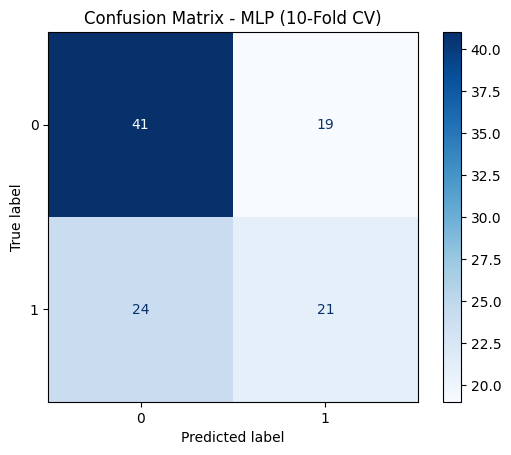

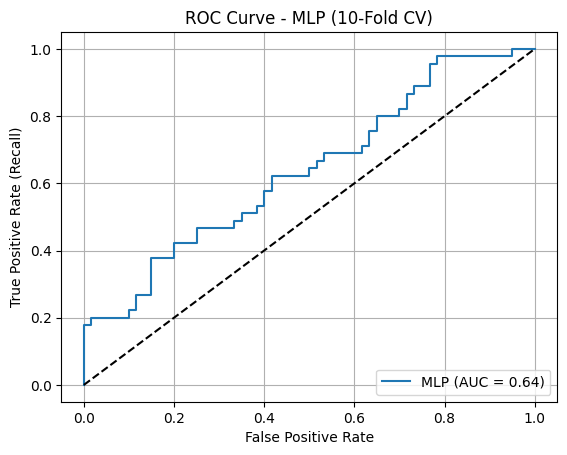

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)
from imblearn.over_sampling import SMOTE

# without feature selection
# X_selected = combined_df.drop(columns=["Label"])
# y_selected = combined_df["Label"]

X_selected = df_power.drop(columns=["Label"])
y_selected = df_power["Label"]

# Initialize MLP model
mlp = MLPClassifier(hidden_layer_sizes=(256, 128,62, 32), activation='relu', solver='adam',
                    max_iter=500, random_state=42)

# Cross-validator
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Tracking
y_true, y_pred, y_proba = [], [], []

# 10-Fold CV loop
for train_idx, test_idx in kf.split(X_selected, y_selected):
    X_train_orig, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_train_orig, y_test = y_selected.iloc[train_idx], y_selected.iloc[test_idx]

    # SMOTE only on training data
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train_orig, y_train_orig)

    # Train model
    mlp.fit(X_train, y_train)

    # Predict
    pred = mlp.predict(X_test)
    proba = mlp.predict_proba(X_test)[:, 1]

    y_true.extend(y_test)
    y_pred.extend(pred)
    y_proba.extend(proba)

# Evaluation
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_proba = np.array(y_proba)

# Metrics
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
auc = roc_auc_score(y_true, y_proba)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred))
#print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1-score     : {f1:.4f}")
print(f"Sensitivity  : {sensitivity:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"AUC Score    : {auc:.4f}")

# Confusion Matrix Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - MLP (10-Fold CV)")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_proba)
plt.plot(fpr, tpr, label=f"MLP (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - MLP (10-Fold CV)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# LSTM Pytorch

In [ ]:
import torch 
torch.cuda.device_count()
torch.cuda.get_device_name()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

In [ ]:
X = np.array(df_power.drop(columns=["Label"]), dtype = np.float64)
y = np.array(df_power["Label"], dtype=np.float64)


===== Fold 1 =====
Early stopping triggered.
Fold 1 Summary:
  Final Training Loss: 0.2103, Accuracy: 0.9694
  Final Validation Loss: 0.6191, Accuracy: 0.8000

===== Fold 2 =====
Early stopping triggered.
Fold 2 Summary:
  Final Training Loss: 0.3801, Accuracy: 0.9490
  Final Validation Loss: 0.7172, Accuracy: 0.5000

===== Fold 3 =====
Early stopping triggered.
Fold 3 Summary:
  Final Training Loss: 0.3537, Accuracy: 0.9592
  Final Validation Loss: 0.7208, Accuracy: 0.6000

===== Fold 4 =====
Early stopping triggered.
Fold 4 Summary:
  Final Training Loss: 0.0418, Accuracy: 1.0000
  Final Validation Loss: 0.2996, Accuracy: 0.8000

===== Fold 5 =====
Early stopping triggered.
Fold 5 Summary:
  Final Training Loss: 0.2102, Accuracy: 0.9796
  Final Validation Loss: 0.6510, Accuracy: 0.8000

===== Fold 6 =====
Early stopping triggered.
Fold 6 Summary:
  Final Training Loss: 0.1378, Accuracy: 1.0000
  Final Validation Loss: 0.6273, Accuracy: 0.6000

===== Fold 7 =====
Early stopping trigg

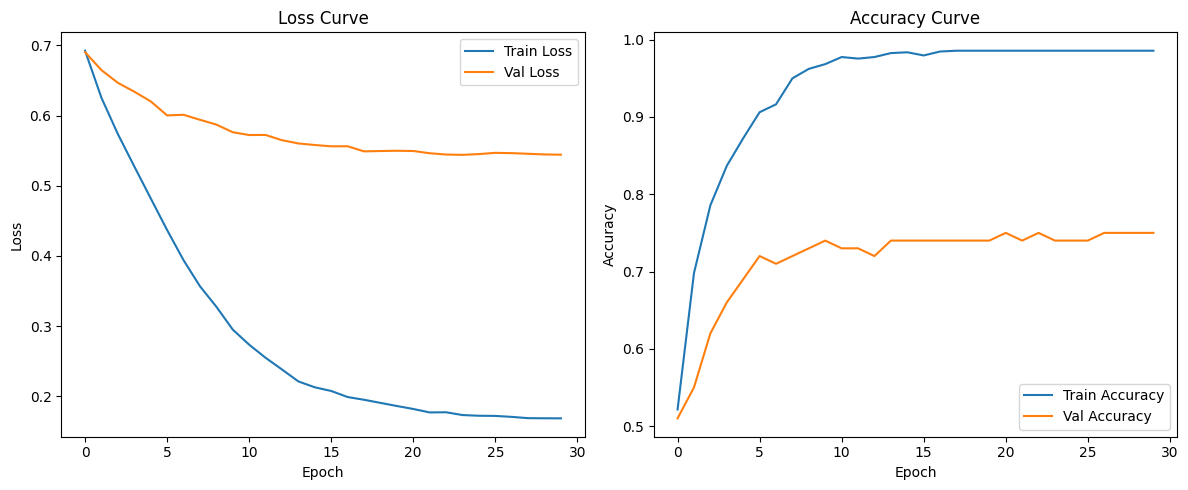


=== Final Evaluation After 10-Fold Cross-Validation ===
Accuracy     : 0.6095
Precision    : 0.5476
Sensitivity  : 0.5111
Specificity  : 0.6833
F1 Score     : 0.5287
AUC          : 0.6481

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.6508    0.6833    0.6667        60
           1     0.5476    0.5111    0.5287        45

    accuracy                         0.6095       105
   macro avg     0.5992    0.5972    0.5977       105
weighted avg     0.6066    0.6095    0.6076       105



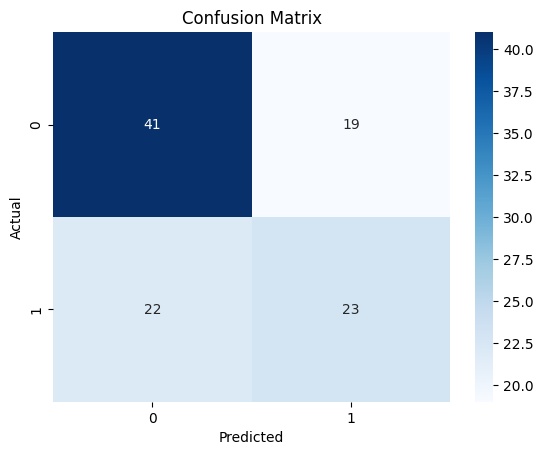

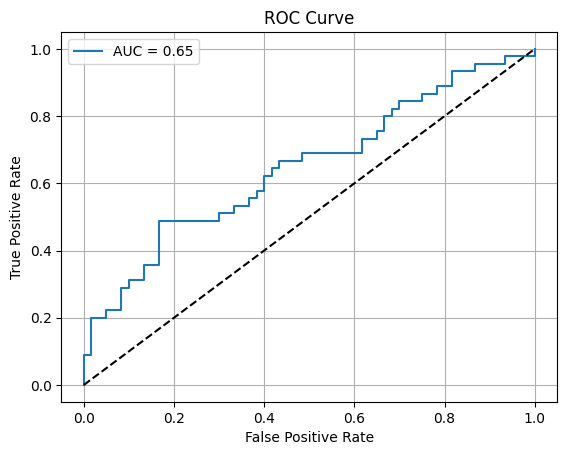

In [101]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, confusion_matrix,
    roc_auc_score, roc_curve, classification_report, f1_score
)
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import shuffle
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# ==== Your normalized waveform dataset ====
X = np.array(df_power.drop(columns=["Label"]), dtype=np.float32)
y = np.array(df_power["Label"], dtype=np.float32)

# ==== BLSTM Model ====
class BLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(BLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=1, bidirectional=True, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.dropout(lstm_out[:, -1, :])
        out = self.fc(out)
        return out

# ==== Evaluation Metrics ====
def evaluate_metrics(y_true, y_pred, y_probs):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)
    auc = roc_auc_score(y_true, y_probs)
    return acc, prec, recall, f1, specificity, auc

# ==== Plots ====
def plot_roc_curve(y_true, y_probs):
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    auc_score = roc_auc_score(y_true, y_probs)
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()
    plt.show()

def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

def plot_loss_accuracy(train_loss, val_loss, train_acc, val_acc):
    epochs = len(train_loss)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(range(epochs), train_loss, label="Train Loss")
    plt.plot(range(epochs), val_loss, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss Curve")

    plt.subplot(1, 2, 2)
    plt.plot(range(epochs), train_acc, label="Train Accuracy")
    plt.plot(range(epochs), val_acc, label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy Curve")

    plt.tight_layout()
    plt.show()

# ==== Cross-validation ====
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
all_true, all_preds, all_probs = [], [], []

avg_train_losses = []
avg_val_losses = []
avg_train_accs = []
avg_val_accs = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n===== Fold {fold} =====")
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    # Apply SMOTE
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    X_train_res, y_train_res = shuffle(X_train_res, y_train_res, random_state=42)

    # Torch tensors and reshape for BLSTM
    X_tensor = torch.tensor(X_train_res).unsqueeze(1)
    y_tensor = torch.tensor(y_train_res, dtype=torch.long)

    dataset = TensorDataset(X_tensor, y_tensor)
    val_size = int(0.1 * len(dataset))
    train_size = len(dataset) - val_size
    train_ds, val_ds = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=4, shuffle=False)

    # Model setup
    model = BLSTM(input_size=235, hidden_size=16, num_classes=2)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-6)

    # Training with early stopping
    max_epochs = 50
    best_val_loss = float('inf')
    patience, patience_counter = 5, 0

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(max_epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            out = model(xb)
            loss = criterion(out, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = torch.argmax(out, dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                out = model(xb)
                loss = criterion(out, yb)
                val_loss += loss.item()
                preds = torch.argmax(out, dim=1)
                correct += (preds == yb).sum().item()
                total += yb.size(0)

        val_loss /= len(val_loader)
        val_acc = correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    # Print fold summary
    print(f"Fold {fold} Summary:")
    print(f"  Final Training Loss: {train_losses[-1]:.4f}, Accuracy: {train_accuracies[-1]:.4f}")
    print(f"  Final Validation Loss: {val_losses[-1]:.4f}, Accuracy: {val_accuracies[-1]:.4f}")

    # Save for averaging later
    avg_train_losses.append(train_losses)
    avg_val_losses.append(val_losses)
    avg_train_accs.append(train_accuracies)
    avg_val_accs.append(val_accuracies)

    # Final test evaluation
    model.eval()
    X_test_tensor = torch.tensor(X_test).unsqueeze(1)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    with torch.no_grad():
        probs = torch.softmax(model(X_test_tensor), dim=1)[:, 1].numpy()
        preds = torch.argmax(model(X_test_tensor), dim=1).numpy()

    all_true.extend(y_test_tensor.numpy())
    all_preds.extend(preds)
    all_probs.extend(probs)

# ==== Plot average loss/accuracy across all folds ====
max_len = max(len(l) for l in avg_train_losses)

def pad_and_avg(list_of_lists):
    padded = [l + [l[-1]] * (max_len - len(l)) for l in list_of_lists]
    return np.mean(padded, axis=0)

plot_loss_accuracy(
    train_loss=pad_and_avg(avg_train_losses),
    val_loss=pad_and_avg(avg_val_losses),
    train_acc=pad_and_avg(avg_train_accs),
    val_acc=pad_and_avg(avg_val_accs)
)

# ==== Final Metrics ====
acc, prec, recall, f1, spec, auc = evaluate_metrics(all_true, all_preds, all_probs)

print("\n=== Final Evaluation After 10-Fold Cross-Validation ===")
print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {prec:.4f}")
print(f"Sensitivity  : {recall:.4f}")
print(f"Specificity  : {spec:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"AUC          : {auc:.4f}")

print("\n=== Classification Report ===")
print(classification_report(all_true, all_preds, digits=4))

plot_confusion_matrix(all_true, all_preds)
plot_roc_curve(all_true, all_probs)


# Results

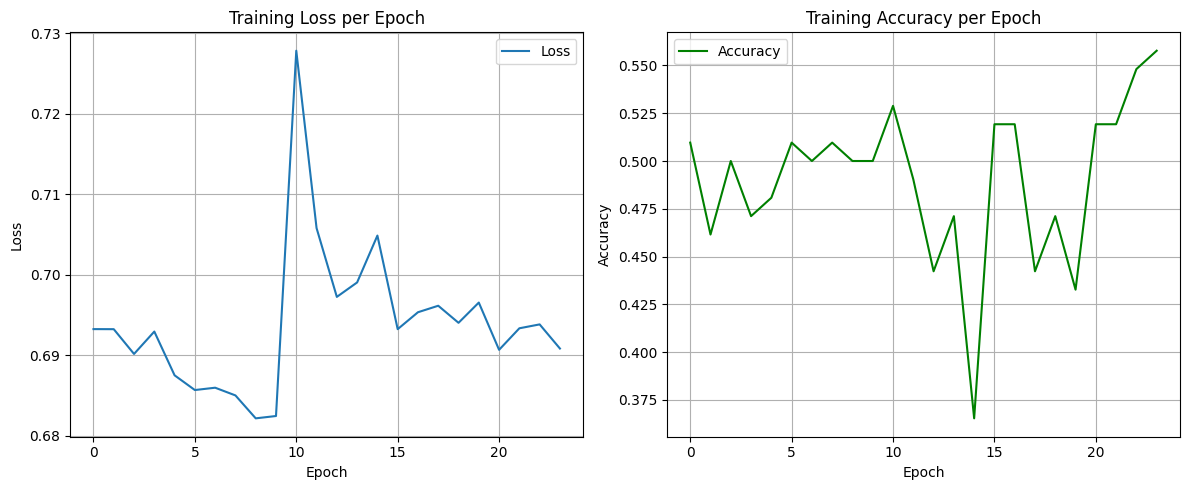

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_history, label='Loss')
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(accuracy_history, label='Accuracy', color='green')
plt.title("Training Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# Saving the model

In [ ]:
# Save the entire model
torch.save(model, 'bilstm_model.pth')

# Or save just the weights (recommended)
torch.save(model.state_dict(), 'bilstm_weights.pth')


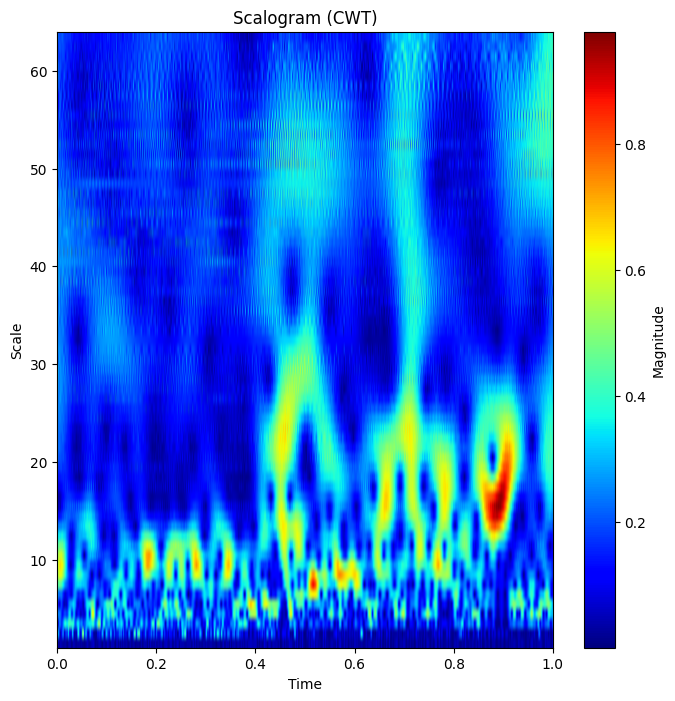

In [ ]:
import numpy as np
import pywt
import matplotlib.pyplot as plt

# Example 1D signal (replace with your real signal)
signal = np.sin(2 * np.pi * 7 * np.linspace(0, 1, 256)) + np.random.randn(256) * 0.2
asd_s=asd_data.iloc[0].values

# Define wavelet and scales
wavelet = 'cmor1.5-1.0'  # Complex Morlet wavelet
scales = np.arange(1, 64)

# Compute CWT
coefficients, frequencies = pywt.cwt(asd_s, scales, wavelet)

# Plot scalogram (magnitude of CWT)
plt.figure(figsize=(8, 8))
plt.imshow(np.abs(coefficients), extent=[0, 1, 1, 64], cmap='jet', aspect='auto', origin='lower')
plt.title('Scalogram (CWT)')
plt.xlabel('Time')
plt.ylabel('Scale')
plt.colorbar(label='Magnitude')
plt.show()


In [ ]:
plt.imsave('scalogram_asd.png', np.abs(coefficients), cmap='jet')

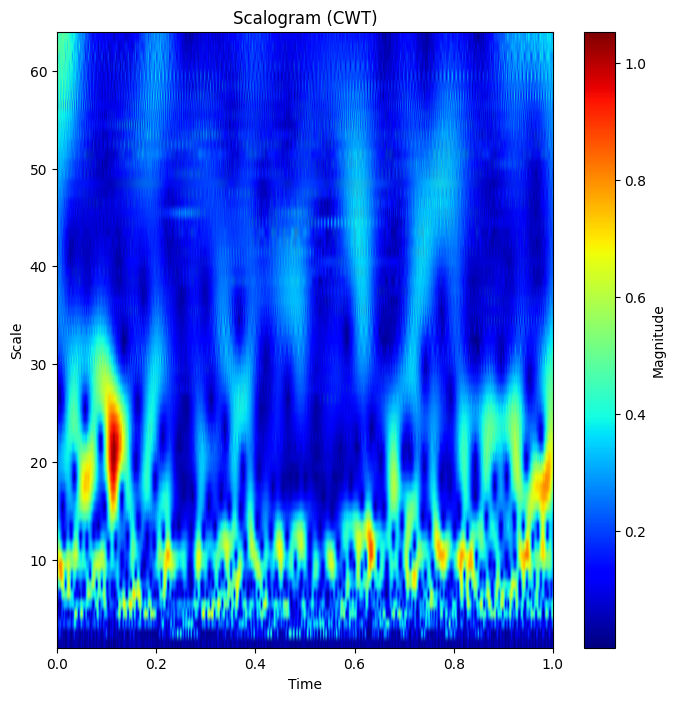

In [ ]:
import numpy as np
import pywt
import matplotlib.pyplot as plt

# Example 1D signal (replace with your real signal)
signal = np.sin(2 * np.pi * 7 * np.linspace(0, 1, 256)) + np.random.randn(256) * 0.2
control_s=control_data.iloc[0].values

# Define wavelet and scales
wavelet = 'cmor1.5-1.0'  # Complex Morlet wavelet
scales = np.arange(1, 64)

# Compute CWT
coefficients, frequencies = pywt.cwt(control_s, scales, wavelet)

# Plot scalogram (magnitude of CWT)
plt.figure(figsize=(8, 8))
plt.imshow(np.abs(coefficients), extent=[0, 1, 1, 64], cmap='jet', aspect='auto', origin='lower')
plt.title('Scalogram (CWT)')
plt.xlabel('Time')
plt.ylabel('Scale')
plt.colorbar(label='Magnitude')
plt.show()


In [ ]:
plt.imsave('scalogram_control.png', np.abs(coefficients), cmap='jet')


# Sktime

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from sklearn.utils import shuffle
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)

from sktime.classification.deep_learning.lstmfcn import LSTMFCNClassifier
from sktime.datatypes._panel._convert import from_2d_array_to_nested


# ==== Dataset Preparation ====
# Assuming df_power is a pandas DataFrame with features and a 'Label' column
X = np.array(combined_df.drop(columns=["Label"]), dtype=np.float32)
y = np.array(combined_df["Label"], dtype=np.int32)

# ==== Apply SMOTE ====
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)
X_res, y_res = shuffle(X_res, y_res, random_state=42)

# ==== Convert to sktime format ====
X_nested = from_2d_array_to_nested(X_res)

# ==== Evaluation Utilities ====
def evaluate_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)
    return acc, prec, recall, f1, specificity

def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

def plot_roc_curve(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc = roc_auc_score(y_true, y_scores)
    plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid()
    plt.show()

# ==== 10-Fold Cross-Validation ====
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
all_true, all_preds, all_probs = [], [], []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_nested, y_res), 1):
    print(f"\n===== Fold {fold} =====")

    X_train, X_test = X_nested.iloc[train_idx], X_nested.iloc[test_idx]
    y_train, y_test = y_res[train_idx], y_res[test_idx]

    clf = LSTMFCNClassifier(n_epochs=50, batch_size=4, random_state=42, verbose=False)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    all_true.extend(y_test)
    all_preds.extend(y_pred)
    all_probs.extend(y_proba)

# ==== Final Metrics ====
acc, prec, recall, f1, spec = evaluate_metrics(all_true, all_preds)
auc = roc_auc_score(all_true, all_probs)

print("\n=== Final Evaluation After 10-Fold Cross-Validation ===")
print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {prec:.4f}")
print(f"Sensitivity  : {recall:.4f}")
print(f"Specificity  : {spec:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"AUC          : {auc:.4f}")

print("\n=== Classification Report ===")
print(classification_report(all_true, all_preds, digits=4))

plot_confusion_matrix(all_true, all_preds)
plot_roc_curve(all_true, all_probs)


In [1]:
pwd

'/home/tanvirdell3/Downloads/ASDvsControl'